
# FedKD-MR — DATASET: HAR

### J. Reyes-Ortiz, D. Anguita, A. Ghio, L. Oneto, and X. Parra. "Human Activity Recognition Using Smartphones," UCI Machine Learning Repository, 2013. [Online]. Available: https://doi.org/10.24432/C54S4K.

# FedKD-MR — DATASET: OPPORTUNITY
### Roggen, D., Calatroni, A., Nguyen-Dinh, L., Chavarriaga, R., & Sagha, H. (2010). OPPORTUNITY Activity Recognition [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5M027.
### @misc{opportunity_activity_recognition_226,
###  author       = {Roggen, Daniel, Calatroni, Alberto, Nguyen-Dinh, Long-Van, Chavarriaga, Ricardo, and Sagha, Hesam},
###  title        = {{OPPORTUNITY Activity Recognition}},
###  year         = {2010},
###  howpublished = {UCI Machine Learning Repository},
###  note         = {{DOI}: https://doi.org/10.24432/C5M027}}

# FedKD-MR — DATASET: WISDM
#Jennifer R. Kwapisz, Gary M. Weiss and Samuel A. Moore (2010). Activity Recognition using Cell Phone Accelerometers, Proceedings of the Fourth International Workshop on Knowledge Discovery from Sensor Data (at KDD-10), Washington DC

## Versão (FedKD_MR_v02_har_only_01)consolidade para o dataset HAR.
## A versão FedKD_MR_v03_har_opportunity_01 introduz o dataset Opportunity sem quebrar o HAR
## A versão FedKD_MR_v04_har_opportunity_wisdm_01 introduz o dataset Wisdm sem quebrar o Opportunity
## Este notebook está consolidado no sentidode funcional para os 3 datasets



In [4]:
#ID = 00 — Montagem segura do Google Drive (Colab)

# #!rm -rf /content/drive

#from google.colab import drive
#drive.mount('/content/drive', force_remount=False)


In [ ]:
#ID = 01 — Imports globais
# -------------------------------------------------
import os
import json
import random
import time
import copy

from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms

from tqdm.auto import tqdm

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


## Plano de refinamento de hiperparâmetros — UCI-HAR

A estratégia de refinamento foi organizada em blocos curtos e sequenciais, com o objetivo de evitar busca exaustiva e isolar o efeito dos hiperparâmetros mais promissores. A ordem adotada prioriza, primeiro, a qualidade e a cobertura do sinal público usado na distilação; depois, a forma como esse sinal é transferido aos modelos locais; em seguida, o quanto esse ganho é preservado após o fine-tuning supervisionado local; e, por fim, um bloco opcional de ajuste da intensidade do KD local.

### Tabela de experimentos sugeridos

| Bloco | Exp | Objetivo | PUBLIC_SIZE | TEACHER_SHARP_TAU | TEMPERATURE_KD | EPOCHS_FINE | LR_FINE | EPOCHS_KD_LOCAL | LR_KD_LOCAL | Decisão esperada |
|---|---|---|---:|---:|---:|---:|---:|---:|---:|---|
| Etapa 0 | E0 | Reexecutar a configuração de referência com `drop_last=False` para obter um baseline limpo | 300 | 1.0 | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Estabelecer novo ponto de comparação confiável |
| Bloco A | A1 | Avaliar maior cobertura pública mantendo o sharpening atual | 512 | 0.7 | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Verificar se o gargalo está na cobertura de `D_pub` |
| Bloco A | A2 | Avaliar maior cobertura pública sem sharpening | 512 | 1.0 | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Verificar se o teacher atual está excessivamente confiante |
| Bloco A | A3 | Avaliar cobertura pública ainda maior mantendo o sharpening atual | 1024 | 0.7 | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Verificar se ainda há subcobertura do espaço público |
| Bloco A | A4 | Avaliar cobertura pública ainda maior sem sharpening | 1024 | 1.0 | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Testar combinação de maior cobertura com teacher menos rígido |
| Bloco B | B1 | Testar KD mais forte, com menor temperatura | melhor do bloco A | melhor do bloco A | 2.0 | 10 | 3e-4 | 8 | 5e-4 | Verificar se o teacher já está bom e precisa ser transferido de forma mais incisiva |
| Bloco B | B2 | Manter temperatura intermediária como referência | melhor do bloco A | melhor do bloco A | 4.0 | 10 | 3e-4 | 8 | 5e-4 | Servir como referência do bloco |
| Bloco B | B3 | Testar KD mais suave, com maior temperatura | melhor do bloco A | melhor do bloco A | 6.0 | 10 | 3e-4 | 8 | 5e-4 | Verificar se relações interclasses mais suaves melhoram a transferência |
| Bloco C | C1 | Reduzir a duração do fine-tuning local | melhor do bloco B | melhor do bloco B | melhor do bloco B | 5 | 3e-4 | 8 | 5e-4 | Verificar se o FT está sobrescrevendo o ganho do KD por excesso de passos |
| Bloco C | C2 | Reduzir a agressividade do fine-tuning pela taxa de aprendizado | melhor do bloco B | melhor do bloco B | melhor do bloco B | 10 | 1e-4 | 8 | 5e-4 | Verificar se o FT está sobrescrevendo o ganho do KD por passo muito forte |
| Bloco C | C3 | Reduzir simultaneamente duração e taxa do fine-tuning | melhor do bloco B | melhor do bloco B | melhor do bloco B | 5 | 1e-4 | 8 | 5e-4 | Testar cenário mais conservador para preservar o ganho do KD |
| Bloco C | C4 | Testar configuração intermediária de fine-tuning | melhor do bloco B | melhor do bloco B | melhor do bloco B | 7 | 2e-4 | 8 | 5e-4 | Buscar equilíbrio entre adaptação local e preservação do conhecimento global |
| Bloco D (opcional) | D1 | Referência do KD local | melhor final | melhor final | melhor final | melhor final | melhor final | 8 | 5e-4 | Servir como base do bloco opcional |
| Bloco D (opcional) | D2 | Aumentar duração do KD local | melhor final | melhor final | melhor final | melhor final | melhor final | 12 | 5e-4 | Verificar se os clientes estão absorvendo pouco o teacher |
| Bloco D (opcional) | D3 | Aumentar taxa do KD local | melhor final | melhor final | melhor final | melhor final | melhor final | 8 | 1e-3 | Verificar se o update de KD está tímido |
| Bloco D (opcional) | D4 | Aumentar duração e taxa do KD local | melhor final | melhor final | melhor final | melhor final | melhor final | 12 | 1e-3 | Testar KD local mais intenso após estabilização dos demais blocos |

### Critério de progressão entre blocos

Ao final de cada bloco, a configuração vencedora deve ser escolhida prioritariamente com base em:

1. maior `mean_delta_acc`;
2. maior número de clientes que melhoram em relação ao Pré-KD;
3. maior `acc_mean`;
4. maior `acc_min`;
5. maior `jain_acc`;
6. menor `acc_std`.

### Interpretação dos blocos

- **Etapa 0** estabelece uma referência limpa, garantindo que `PUBLIC_SIZE` seja efetivamente respeitado ao usar `drop_last=False`.
- **Bloco A** testa se o ganho limitado do FedKD-MR decorre de cobertura insuficiente do conjunto público ou de excesso de confiança no teacher global.
- **Bloco B** testa se a transferência do conhecimento do teacher para os clientes está subótima por escolha inadequada da temperatura de KD.
- **Bloco C** testa se o ganho do KD está sendo parcialmente apagado pelo fine-tuning local supervisionado.
- **Bloco D**, opcional, só deve ser executado se os blocos anteriores produzirem melhora, mas ainda houver indícios de subaproveitamento do teacher durante o KD local.

In [ ]:
# ID = 02 — Configuração central do experimento (UCI-HAR)
# -------------------------------------------------------
# Objetivo:
# Centralizar TODOS os parâmetros editáveis do experimento
# em um único lugar, evitando redefinições espalhadas.

from pathlib import Path

# =========================================================
# 1) Reprodutibilidade
# =========================================================
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"SEED={SEED}, DEVICE={DEVICE}")

# =========================================================
# 2) Identificação do experimento
# =========================================================
EXPERIMENT_ID =  "UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5" #HAR_E5_partial_coverage_1024_T3_tau07_FT8"


# Escolha do modo de D_pub
PUBLIC_MODE = "partial_coverage"   # "representative", "partial_coverage", "imbalanced", "random"

# =========================================================
# 3) Configuração principal do dataset / protocolo
# =========================================================
EXPERIMENT_CFG = {
    "experiment_id": EXPERIMENT_ID,
    "dataset": "UCI_HAR", #UCI_HAR
    "n_rounds": 5,
    "num_workers": 0,

    "public_size": 512,
    "public_batch_size": 256,
    "public_drop_last": False,

    "public_sampling_mode": PUBLIC_MODE,
}

# Configurações específicas por modo
if PUBLIC_MODE == "partial_coverage":
    EXPERIMENT_CFG["public_partial_drop_classes"] = [4]

elif PUBLIC_MODE == "imbalanced":
    EXPERIMENT_CFG["public_imbalance_map"] = {4: 0.25}
    EXPERIMENT_CFG["public_imbalance_strength"] = 0.7

elif PUBLIC_MODE == "representative":
    # Opportunity: classe 4 (lie) é rara no pool — drop necessário
    # para viabilizar amostragem representativa estrita entre classes restantes
    if EXPERIMENT_CFG["dataset"] == "OPPORTUNITY":
        EXPERIMENT_CFG["public_partial_drop_classes"] = [4]

elif PUBLIC_MODE == "random":
    pass

else:
    raise ValueError(f"Modo inválido de D_pub: {PUBLIC_MODE}")

# Atalho semântico
DATASET_NAME = EXPERIMENT_CFG["dataset"]

# =========================================================
# 4) Hiperparâmetros do Pré-KD
# =========================================================
PREKD_CFG = {
    "epochs": 40,
    "lr": 5e-4,
    "weight_decay": 5e-4,
    "max_grad_norm": 5.0,
}

# =========================================================
# 5) Hiperparâmetros do FedKD-MR
# =========================================================
FEDKD_CFG = {
    # protocolo
    "n_rounds": EXPERIMENT_CFG["n_rounds"],

    # teacher / KD
    "temperature_kd": 3.0,  # era 4.
    "teacher_sharp_tau": 0.7,   # 1.0 = sem sharpening; <1 = mais confiante

    # KD local no conjunto público
    "epochs_kd_local": 8,
    "lr_kd_local": 5e-4,
    "wd_kd_local": 5e-4,
    "max_grad_norm_kd": 5.0,

    # fine-tuning supervisionado local
    "epochs_fine": 8,  # era 5, mudei para 8, 7 agora
    "lr_fine": 1e-4,
    "wd_fine": 3e-4,
    "ft_max_grad_norm": 5.0,
}

# =========================================================
# 6) Hiperparâmetros dos baselines federados
# =========================================================
BASELINE_CFG = {
    "comparison_mode": "light_baseline",   # "light_baseline" ou "budget_matched"
    "n_rounds": EXPERIMENT_CFG["n_rounds"],

    # otimização local
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 64,
    "max_grad_norm": 5.0,

    # FedProx
    "fedprox_mu": 0.01,
}

if BASELINE_CFG["comparison_mode"] == "light_baseline":
    BASELINE_CFG["local_epochs"] = 1
elif BASELINE_CFG["comparison_mode"] == "budget_matched":
    BASELINE_CFG["local_epochs"] = 5
else:
    raise ValueError(f"Modo inválido: {BASELINE_CFG['comparison_mode']}")

# =========================================================
# 7) Exporta aliases planos para compatibilidade com o notebook
# =========================================================
# ---- protocolo geral
N_ROUNDS = FEDKD_CFG["n_rounds"]

# ---- D_pub
# ---- D_pub
PUBLIC_SIZE = EXPERIMENT_CFG["public_size"]
PUBLIC_BATCH_SIZE = EXPERIMENT_CFG["public_batch_size"]
PUBLIC_DROP_LAST = EXPERIMENT_CFG["public_drop_last"]

PUBLIC_SAMPLING_MODE = EXPERIMENT_CFG["public_sampling_mode"]
PUBLIC_PARTIAL_DROP_CLASSES = EXPERIMENT_CFG.get("public_partial_drop_classes", [])
PUBLIC_IMBALANCE_MAP = EXPERIMENT_CFG.get("public_imbalance_map", {})
PUBLIC_IMBALANCE_STRENGTH = EXPERIMENT_CFG.get("public_imbalance_strength", None)

# Não sobrescrever o modo aqui; apenas ler o que foi definido em EXPERIMENT_CFG
PUBLIC_SAMPLING_MODE = EXPERIMENT_CFG["public_sampling_mode"]

# Parâmetros opcionais por modo
PUBLIC_PARTIAL_DROP_CLASSES = EXPERIMENT_CFG.get("public_partial_drop_classes", [])
PUBLIC_IMBALANCE_MAP = EXPERIMENT_CFG.get("public_imbalance_map", {})
PUBLIC_IMBALANCE_STRENGTH = EXPERIMENT_CFG.get("public_imbalance_strength", None)

# ---- Pré-KD
PREKD_EPOCHS = PREKD_CFG["epochs"]
PREKD_LR = PREKD_CFG["lr"]
PREKD_WEIGHT_DECAY = PREKD_CFG["weight_decay"]
PREKD_MAX_GRAD_NORM = PREKD_CFG["max_grad_norm"]

# ---- FedKD-MR
TEMPERATURE_KD = FEDKD_CFG["temperature_kd"]
TEACHER_SHARP_TAU = FEDKD_CFG["teacher_sharp_tau"]

EPOCHS_KD_LOCAL = FEDKD_CFG["epochs_kd_local"]
LR_KD_LOCAL = FEDKD_CFG["lr_kd_local"]
WD_KD_LOCAL = FEDKD_CFG["wd_kd_local"]
MAX_GRAD_NORM_KD = FEDKD_CFG["max_grad_norm_kd"]

EPOCHS_FINE = FEDKD_CFG["epochs_fine"]
LR_FINE = FEDKD_CFG["lr_fine"]
WD_FINE = FEDKD_CFG["wd_fine"]
FT_MAX_GRAD_NORM = FEDKD_CFG["ft_max_grad_norm"]

# ---- Baselines
BASELINE_COMPARISON_MODE = BASELINE_CFG["comparison_mode"]
LOCAL_EPOCHS = BASELINE_CFG["local_epochs"]
LR = BASELINE_CFG["lr"]
WEIGHT_DECAY = BASELINE_CFG["weight_decay"]
BATCH_SIZE = BASELINE_CFG["batch_size"]
MAX_GRAD_NORM = BASELINE_CFG["max_grad_norm"]
FEDPROX_MU = BASELINE_CFG["fedprox_mu"]

# =========================================================
# 8) Diretórios
# =========================================================
BASE_RESULTS_DIR = Path("/content/drive/MyDrive/FedKD_MR_HAR_results")

RESULTS_DIR = BASE_RESULTS_DIR / EXPERIMENT_ID
METRICS_DIR = RESULTS_DIR / "metrics"
ARTIFACTS_DIR = RESULTS_DIR / "artifacts"

for d in [RESULTS_DIR, METRICS_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =========================================================
# 9) Resumo da configuração ativa
# =========================================================
print("\n================ CONFIGURAÇÃO ATIVA ================")
print(f"EXPERIMENT_ID           = {EXPERIMENT_ID}")
print(f"DATASET                 = {DATASET_NAME}")
print(f"N_ROUNDS                = {N_ROUNDS}")
print(f"PUBLIC_SIZE             = {PUBLIC_SIZE}")
print(f"PUBLIC_BATCH_SIZE       = {PUBLIC_BATCH_SIZE}")
print(f"PUBLIC_DROP_LAST        = {PUBLIC_DROP_LAST}")

print("\n--- PRE-KD ---")
print(f"PREKD_EPOCHS            = {PREKD_EPOCHS}")
print(f"PREKD_LR                = {PREKD_LR}")
print(f"PREKD_WEIGHT_DECAY      = {PREKD_WEIGHT_DECAY}")
print(f"PREKD_MAX_GRAD_NORM     = {PREKD_MAX_GRAD_NORM}")

print("\n--- FEDKD-MR ---")
print(f"TEMPERATURE_KD          = {TEMPERATURE_KD}")
print(f"TEACHER_SHARP_TAU       = {TEACHER_SHARP_TAU}")
print(f"EPOCHS_KD_LOCAL         = {EPOCHS_KD_LOCAL}")
print(f"LR_KD_LOCAL             = {LR_KD_LOCAL}")
print(f"WD_KD_LOCAL             = {WD_KD_LOCAL}")
print(f"MAX_GRAD_NORM_KD        = {MAX_GRAD_NORM_KD}")
print(f"EPOCHS_FINE             = {EPOCHS_FINE}")
print(f"LR_FINE                 = {LR_FINE}")
print(f"WD_FINE                 = {WD_FINE}")
print(f"FT_MAX_GRAD_NORM        = {FT_MAX_GRAD_NORM}")

print("\n--- BASELINES ---")
print(f"BASELINE_MODE           = {BASELINE_COMPARISON_MODE}")
print(f"LOCAL_EPOCHS            = {LOCAL_EPOCHS}")
print(f"LR                      = {LR}")
print(f"WEIGHT_DECAY            = {WEIGHT_DECAY}")
print(f"BATCH_SIZE              = {BATCH_SIZE}")
print(f"MAX_GRAD_NORM           = {MAX_GRAD_NORM}")
print(f"FEDPROX_MU              = {FEDPROX_MU}")

print("\n--- PATHS ---")
print(f"RESULTS_DIR             = {RESULTS_DIR}")
print(f"METRICS_DIR             = {METRICS_DIR}")
print(f"ARTIFACTS_DIR           = {ARTIFACTS_DIR}")
print("====================================================\n")

SEED=42, DEVICE=cuda

================ CONFIGURAÇÃO ATIVA ================
EXPERIMENT_ID           = UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5
DATASET                 = UCI_HAR
N_ROUNDS                = 5
PUBLIC_SIZE             = 512
PUBLIC_BATCH_SIZE       = 256
PUBLIC_DROP_LAST        = False

--- PRE-KD ---
PREKD_EPOCHS            = 40
PREKD_LR                = 0.0005
PREKD_WEIGHT_DECAY      = 0.0005
PREKD_MAX_GRAD_NORM     = 5.0

--- FEDKD-MR ---
TEMPERATURE_KD          = 3.0
TEACHER_SHARP_TAU       = 0.7
EPOCHS_KD_LOCAL         = 8
LR_KD_LOCAL             = 0.0005
WD_KD_LOCAL             = 0.0005
MAX_GRAD_NORM_KD        = 5.0
EPOCHS_FINE             = 8
LR_FINE                 = 0.0001
WD_FINE                 = 0.0003
FT_MAX_GRAD_NORM        = 5.0

--- BASELINES ---
BASELINE_MODE           = light_baseline
LOCAL_EPOCHS            = 1
LR                      = 0.001
WEIGHT_DECAY            = 0.0001
BATCH_SIZE              = 64
MAX_GRAD_NORM           = 5.0
FEDPROX_MU    

In [ ]:
# ID = 02B — Salvar configuração do experimento
# ---------------------------------------------
import json
from datetime import datetime

EXPERIMENT_CONFIG_SNAPSHOT = {
    "experiment_id": EXPERIMENT_ID,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": DATASET_NAME,
    "seed": SEED,
    "device": DEVICE,

    "protocol": {
        "n_rounds": N_ROUNDS,
        "public_size": PUBLIC_SIZE,
        "public_batch_size": PUBLIC_BATCH_SIZE,
        "public_drop_last": PUBLIC_DROP_LAST,
        "public_sampling_mode": EXPERIMENT_CFG.get("public_sampling_mode", "random"),
        "public_partial_drop_classes": EXPERIMENT_CFG.get("public_partial_drop_classes", []),
        "public_imbalance_map": EXPERIMENT_CFG.get("public_imbalance_map", {}),
    },
    "architecture": {
        "dataset": DATASET_NAME,
        "groups": ["A_TinyML_MLP", "B_CNN1D", "C_GRU"] if DATASET_NAME == "UCI_HAR" else "dataset_specific"
    },
    "prekd": {
        "epochs": PREKD_EPOCHS,
        "lr": PREKD_LR,
        "weight_decay": PREKD_WEIGHT_DECAY,
        "max_grad_norm": PREKD_MAX_GRAD_NORM,
    },

    "fedkd_mr": {
        "temperature_kd": TEMPERATURE_KD,
        "teacher_sharp_tau": TEACHER_SHARP_TAU,
        "epochs_kd_local": EPOCHS_KD_LOCAL,
        "lr_kd_local": LR_KD_LOCAL,
        "wd_kd_local": WD_KD_LOCAL,
        "max_grad_norm_kd": MAX_GRAD_NORM_KD,
        "epochs_fine": EPOCHS_FINE,
        "lr_fine": LR_FINE,
        "wd_fine": WD_FINE,
        "ft_max_grad_norm": FT_MAX_GRAD_NORM,
    },

    "baselines": {
        "comparison_mode": BASELINE_COMPARISON_MODE,
        "local_epochs": LOCAL_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "max_grad_norm": MAX_GRAD_NORM,
        "fedprox_mu": FEDPROX_MU,
    },

    "paths": {
        "results_dir": str(RESULTS_DIR),
        "metrics_dir": str(METRICS_DIR),
        "artifacts_dir": str(ARTIFACTS_DIR),
    },
}


#config_path = RESULTS_DIR / "config_experiment.json"
config_path = RESULTS_DIR / f"{EXPERIMENT_ID}_config_experiment.json.csv"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(EXPERIMENT_CONFIG_SNAPSHOT, f, indent=2, ensure_ascii=False)

print(f"✅ Configuração do experimento salva em: {config_path}")

✅ Configuração do experimento salva em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_config_experiment.json.csv


In [ ]:
# ID = 03 — Função de avaliação de modelo
# ---------------------------------------

def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    device: str = DEVICE,
    return_report: bool = False,
    return_confusion: bool = False,
    average: str = "macro",         # mantido para compatibilidade; calculamos macro e weighted
    topk: tuple = (),               # ex.: (1, 5) para acc@1 e acc@5; vazio = não calcula
    labels: list | None = None,     # lista de rótulos/ordem (0..C-1); None tenta inferir
) -> dict:
    """
    Avalia um modelo num dataloader e retorna um dicionário com:

      - 'acc'
      - 'f1_macro', 'f1_weighted'
      - 'precision_macro', 'recall_macro'
      - 'precision_weighted', 'recall_weighted'

    Opcionalmente:
      - 'report' (classification_report como string) se return_report=True
      - 'confusion_matrix' (np.ndarray CxC) se return_confusion=True
      - 'topk': {'acc@k': float, ...} se topk não for vazio
    """
    was_training = model.training
    model.to(device)
    model.eval()

    all_preds, all_targets = [], []

    with torch.inference_mode():
        for xb, yb in dataloader:
            xb = xb.to(device, non_blocking=False)
            yb = yb.to(device, non_blocking=False)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.detach().cpu())
            all_targets.append(yb.detach().cpu())

    if not all_preds:
        raise RuntimeError("evaluate_model recebeu um dataloader vazio (sem batches).")

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    # Métricas básicas
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average="macro")
    f1w  = f1_score(y_true, y_pred, average="weighted")

    # Precision/Recall em macro & weighted
    p_m, r_m, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    out = {
        "acc": float(acc),
        "f1_macro": float(f1m),
        "f1_weighted": float(f1w),
        "precision_macro": float(p_m),
        "precision_weighted": float(p_w),
        "recall_macro": float(r_m),
        "recall_weighted": float(r_w),
    }

    # Top-K accuracy opcional
    if topk:
        topk = tuple(sorted({int(k) for k in topk if int(k) >= 1}))
        if topk:
            tk_hits = {f"acc@{k}": 0 for k in topk}
            total = 0
            with torch.inference_mode():
                for xb, yb in dataloader:
                    xb = xb.to(device, non_blocking=False)
                    yb = yb.to(device, non_blocking=False)
                    scores = model(xb)
                    total += yb.size(0)
                    max_k = max(topk)
                    _, topk_idx = scores.topk(k=max_k, dim=1, largest=True, sorted=True)
                    for k in topk:
                        hits = (topk_idx[:, :k] == yb.view(-1, 1)).any(dim=1).sum().item()
                        tk_hits[f"acc@{k}"] += hits
            out["topk"] = {k: tk_hits[f"acc@{k}"] / total for k in tk_hits}

    if return_report:
        out["report"] = classification_report(
            y_true, y_pred, digits=4, zero_division=0
        )

    if return_confusion:
        # se labels não vierem, infere ordenando os presentes
        if labels is None:
            labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        out["confusion_matrix"] = cm

    if was_training:
        model.train()

    return out


In [ ]:
# ID = 04 — Model factory (MLP, CNN1D, CNN2D, ResNetMini)
# -------------------------------------------------------
# Suporta:
#   - MLP
#   - CNN1D
#   - CNN2D
#   - ResNetMini (CNN2D residual pequena, p/ Group D)
#   - GRU
# -------------------------------------------------------


class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_batchnorm=True, dropout_rate=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_ch, out_ch,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=not use_batchnorm
            )
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))
        if dropout_rate > 0:
            layers.append(nn.Dropout2d(dropout_rate))

        layers += [
            nn.Conv2d(
                out_ch, out_ch,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=not use_batchnorm
            )
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))

        self.block = nn.Sequential(*layers)

        # atalho (identity ou 1x1 conv se muda canal/stride)
        if stride != 1 or in_ch != out_ch:
            proj_layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False)
            ]
            if use_batchnorm:
                proj_layers.append(nn.BatchNorm2d(out_ch))
            self.shortcut = nn.Sequential(*proj_layers)
        else:
            self.shortcut = nn.Identity()

        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = out + self.shortcut(x)
        return self.act(out)


class ResNetMini(nn.Module):
    """
    ResNet bem pequena.
    Estrutura: stem conv + 3 estágios residuais leves.
    """
    def __init__(self, input_shape, num_classes=100,
                 use_batchnorm=True, dropout_rate=0.0):
        super().__init__()
        C, H, W = input_shape

        self.stem = nn.Sequential(
            nn.Conv2d(
                C, 32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=not use_batchnorm
            ),
            nn.BatchNorm2d(32) if use_batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
        )

        # Três estágios com aumento gradual de canais
        self.layer1 = BasicBlock(
            32, 32, stride=1,
            use_batchnorm=use_batchnorm,
            dropout_rate=dropout_rate
        )
        self.layer2 = BasicBlock(
            32, 64, stride=2,  # downsample
            use_batchnorm=use_batchnorm,
            dropout_rate=dropout_rate
        )
        self.layer3 = BasicBlock(
            64, 128, stride=2,  # downsample
            use_batchnorm=use_batchnorm,
            dropout_rate=dropout_rate
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def create_model(
    input_size,                      # usado no MLP (n_features)
    output_size=100,                 # CIFAR-100 por padrão
    hidden_layers=[128, 64],         # MLP
    activations=['ReLU', 'ReLU'],    # MLP
    model_type='cnn2d',              # para CIFAR-100, cnn2d é default
    use_dropout=True,
    dropout_rate=0.4,
    use_batchnorm=True,
    final_activation=None,           # para CrossEntropyLoss, deixe None
    cnn_channels=[64, 128, 256],     # blocos conv p/ CNNs
    cnn_kernel_size=3,
    cnn_stride=1,
    cnn_padding=1,
    input_shape=None                 # (C, L) p/ 1D ou (C, H, W) p/ 2D
):
    """
    Modelos heterogêneos.

    model_type ∈ { 'mlp', 'cnn1d', 'cnn2d', 'resnetmini' }

    Observações:
    - Para CrossEntropyLoss: final_activation deve ser None (logits crus).
    - Para NLLLoss: use final_activation='LogSoftmax' e ajuste o head.
    """

    def _get_activation(name):
        # Cria instância de ativação a partir do nome (ex.: 'ReLU', 'GELU', etc.)
        if name is None:
            return nn.Identity()
        if hasattr(nn, name):
            return getattr(nn, name)()
        raise ValueError(f"Ativação desconhecida: {name}")

    def _init_weights(m):
        # Inicialização Kaiming para conv/linear; bias = 0
        if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    model_type_lower = model_type.lower()

    # -----------------
    # MLP
    # -----------------
    if model_type_lower == 'mlp':
        layers = []
        in_features = input_size
        layers.append(nn.Flatten(start_dim=1))
        for hidden_size, act in zip(hidden_layers, activations):
            layers.append(nn.Linear(in_features, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(_get_activation(act))
            if use_dropout:
                layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_size

        layers.append(nn.Linear(in_features, output_size))
        if final_activation:
            layers.append(_get_activation(final_activation))

        mlp = nn.Sequential(*layers)
        mlp.apply(_init_weights)
        return mlp

    # -----------------
    # CNN 1D
    # -----------------

    elif model_type_lower == "cnn1d":
        assert input_shape is not None and len(input_shape) == 2
        C, L = input_shape

        conv_blocks = []
        in_ch = C

        for out_ch in cnn_channels:
            conv_blocks += [
                nn.Conv1d(
                    in_ch,
                    out_ch,
                    kernel_size=cnn_kernel_size,
                    stride=cnn_stride,
                    padding=cnn_padding,
                    bias=not use_batchnorm,
                )
            ]
            if use_batchnorm:
                conv_blocks.append(nn.BatchNorm1d(out_ch))
            conv_blocks.append(nn.ReLU())
            if use_dropout:
                conv_blocks.append(nn.Dropout(dropout_rate))
            in_ch = out_ch

        model_1d = nn.Sequential(
            *conv_blocks,
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(in_ch, output_size),
        )
        model_1d.apply(_init_weights)
        return model_1d


    # -----------------
    # CNN 2D
    # -----------------
    elif model_type_lower == 'cnn2d':
        assert input_shape is not None and len(input_shape) == 3, \
            "Para CNN2D, input_shape deve ser (C, H, W)"
        C, H, W = input_shape

        conv_blocks = []
        in_ch = C
        for out_ch in cnn_channels:
            conv_blocks += [
                nn.Conv2d(
                    in_ch, out_ch,
                    kernel_size=cnn_kernel_size,
                    stride=cnn_stride,
                    padding=cnn_padding,
                    bias=not use_batchnorm
                )
            ]
            if use_batchnorm:
                conv_blocks.append(nn.BatchNorm2d(out_ch))
            conv_blocks.append(nn.ReLU())
            # Pooling intermediário para redução espacial
            conv_blocks.append(nn.MaxPool2d(kernel_size=2, stride=2))  # reduz H,W pela metade
            if use_dropout:
                conv_blocks.append(nn.Dropout2d(dropout_rate))
            in_ch = out_ch

        head = [
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_ch, output_size)
        ]
        if final_activation:
            head.append(_get_activation(final_activation))

        model_2d = nn.Sequential(*(conv_blocks + head))
        model_2d.apply(_init_weights)
        return model_2d

    # -----------------
    # ResNetMini 2D
    # -----------------
    elif model_type_lower == 'resnetmini':
        assert input_shape is not None and len(input_shape) == 3, \
            "Para ResNetMini, input_shape deve ser (C, H, W)"
        model = ResNetMini(
            input_shape=input_shape,
            num_classes=output_size,
            use_batchnorm=use_batchnorm,
            dropout_rate=dropout_rate,
        )
        model.apply(_init_weights)
        return model

    # -----------------
    # GRU (LEVE)
    # -----------------
    elif model_type_lower == "gru":
        assert input_shape is not None and len(input_shape) == 2
        C, T = input_shape

        hidden_size = hidden_layers[0] if hidden_layers else 64
        num_layers = 1
        bidirectional = False

        class GRUModel(nn.Module):
            def __init__(self):
                super().__init__()

                self.gru = nn.GRU(
                    input_size=C,
                    hidden_size=hidden_size,
                    num_layers=num_layers,
                    batch_first=True,
                    bidirectional=bidirectional
                )

                out_dim = hidden_size * (2 if bidirectional else 1)
                self.head = nn.Sequential(
                    nn.LayerNorm(out_dim),
                    nn.Dropout(dropout_rate if use_dropout else 0.0),
                    nn.Linear(out_dim, output_size)
                )

            def forward(self, x):
                # x: (B, C, T) -> (B, T, C)
                x = x.permute(0, 2, 1)
                out, _ = self.gru(x)
                out = out[:, -1]
                out = self.head(out)
                return out

        model = GRUModel()
        model.apply(_init_weights)
        return model

    else:
        raise ValueError(f"Tipo de modelo desconhecido: {model_type}")



In [ ]:
# ID = 04B — Dataset HAR
# -------------------------------------------------
class HARDataset(torch.utils.data.Dataset):
    """
    Dataset genérico para Human Activity Recognition (HAR).

    Cada amostra corresponde a uma janela temporal de sensores,
    associada a um rótulo de atividade e a um usuário (device).

    A classe é independente de arquitetura: o formato do tensor
    de saída pode ser ajustado via `tensor_format`.

    Parâmetros
    ----------
    X : np.ndarray ou torch.Tensor
        Dados de entrada no formato:
        - (N, T, S)  -> N janelas, T passos temporais, S sensores
    y : np.ndarray ou torch.Tensor
        Rótulos das atividades (N,)
    user_ids : np.ndarray ou torch.Tensor
        Identificador do usuário para cada janela (N,)
    tensor_format : str
        Define o formato do tensor retornado:
        - "channels_first": (S, T)        -> CNN1D, RNN
        - "flat":             (S*T,)      -> MLP
        - "cnn2d":            (1, S, T)   -> CNN2D (opcional)
    dtype : torch.dtype
        Tipo do tensor retornado (default: torch.float32)
    """

    def __init__(
        self,
        X,
        y,
        user_ids,
        tensor_format: str = "channels_first",
        dtype: torch.dtype = torch.float32,
    ):
        super().__init__()

        assert len(X) == len(y) == len(user_ids), \
            "X, y e user_ids devem ter o mesmo comprimento"

        # Converte para tensor se vier como numpy
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X)
        if isinstance(y, np.ndarray):
            y = torch.from_numpy(y)
        if isinstance(user_ids, np.ndarray):
            user_ids = torch.from_numpy(user_ids)

        self.X = X.to(dtype=dtype)
        self.y = y.long()
        self.user_ids = user_ids.long()
        self.tensor_format = tensor_format

        # Inferência de dimensões básicas
        self.N, self.T, self.S = self.X.shape  # (N, T, S)

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        Xw = self.X[idx]   # (T, S)
        y = self.y[idx]

        if self.tensor_format == "channels_first":
            # (T, S) -> (S, T)
            Xw = Xw.transpose(0, 1)

        elif self.tensor_format == "flat":
            # (T, S) -> (S*T,)
            Xw = Xw.reshape(-1)

        elif self.tensor_format == "cnn2d":
            # (T, S) -> (1, S, T)
            Xw = Xw.transpose(0, 1).unsqueeze(0)

        else:
            raise ValueError(
                f"tensor_format desconhecido: {self.tensor_format}"
            )

        return Xw, y


In [ ]:
# ID = 04C — Split por usuário (HAR)

def split_by_user_ids(dataset: HARDataset):
    """
    Divide um HARDataset em subsets por usuário (device).

    Retorna:
    --------
    dict[user_id] -> lista de índices
    """
    user_to_indices = {}

    for idx in range(len(dataset)):
        uid = int(dataset.user_ids[idx])
        if uid not in user_to_indices:
            user_to_indices[uid] = []
        user_to_indices[uid].append(idx)

    return user_to_indices

In [ ]:
# ID = 05 — UCI HAR: carregamento de sinais inerciais (raw windows)
# ---------------------------------------------------------------

def load_inertial_signals_uci_har(base_path, split):
    """
    Carrega sinais inerciais do UCI HAR (body acceleration).

    Retorno:
    --------
    X : np.ndarray de shape (N, T, S)
        onde:
        - T = 128 timesteps
        - S = 3 sensores (x, y, z)
    """
    inertial_dir = os.path.join(base_path, split, "Inertial Signals")

    signal_files = [
        f"body_acc_x_{split}.txt",
        f"body_acc_y_{split}.txt",
        f"body_acc_z_{split}.txt",
    ]

    signals = []

    for fname in signal_files:
        path = os.path.join(inertial_dir, fname)
        data = np.loadtxt(path)  # shape = (N, 128)
        signals.append(data)

    # Stack final: (N, 128, 3)
    X = np.stack(signals, axis=-1)

    return X

In [ ]:

# ID = 06A — loaders consolidados (UCI-HAR, OPPORTUNITY, WISDM)
# -------------------------------------------------------------

from dataclasses import dataclass
from collections import Counter
import os
import re
import numpy as np
import pandas as pd
from torch.utils.data import Subset


@dataclass
class DatasetBundle:
    train_dataset: object
    test_dataset: object
    full_dataset: object
    train_indices: np.ndarray
    test_indices: np.ndarray
    n_classes: int
    input_shape: tuple
    metadata: dict


In [ ]:
# ID = 06B — loader consolidado (UCI-HAR)
# -------------------------------------------------------------

# =========================================================
# UCI-HAR
# =========================================================
def load_uci_har_dataset(
    dataset_root,
    tensor_format="channels_first",
):
    """
    Carrega o UCI-HAR preservando rigorosamente os splits oficiais.

    Retorna um DatasetBundle com:
      - train_dataset
      - test_dataset
      - full_dataset (apenas para inspeção; NÃO usar para treino/avaliação)
      - train_indices / test_indices relativos ao full_dataset
    """

    # ---------------- TRAIN ----------------
    X_train = load_inertial_signals_uci_har(dataset_root, split="train")

    y_train = np.loadtxt(
        os.path.join(dataset_root, "train", "y_train.txt"),
        dtype=int
    ) - 1

    users_train = np.loadtxt(
        os.path.join(dataset_root, "train", "subject_train.txt"),
        dtype=int
    )

    # ---------------- TEST -----------------
    X_test = load_inertial_signals_uci_har(dataset_root, split="test")

    y_test = np.loadtxt(
        os.path.join(dataset_root, "test", "y_test.txt"),
        dtype=int
    ) - 1

    users_test = np.loadtxt(
        os.path.join(dataset_root, "test", "subject_test.txt"),
        dtype=int
    )

    # ---------------- DATASETS SEPARADOS ----------------
    train_dataset = HARDataset(
        X=X_train,
        y=y_train,
        user_ids=users_train,
        tensor_format=tensor_format,
    )
    train_dataset.split_tag = np.array(["train"] * len(y_train))
    train_dataset.n_classes = int(len(np.unique(y_train)))
    train_dataset.input_shape = (X_train.shape[2], X_train.shape[1])

    test_dataset = HARDataset(
        X=X_test,
        y=y_test,
        user_ids=users_test,
        tensor_format=tensor_format,
    )
    test_dataset.split_tag = np.array(["test"] * len(y_test))
    test_dataset.n_classes = int(len(np.unique(y_test)))
    test_dataset.input_shape = (X_test.shape[2], X_test.shape[1])

    # ---------------- FULL DATASET (APENAS REFERÊNCIA) ----------------
    X_full = np.concatenate([X_train, X_test], axis=0)
    y_full = np.concatenate([y_train, y_test], axis=0)
    users_full = np.concatenate([users_train, users_test], axis=0)
    split_tag_full = np.array(
        ["train"] * len(y_train) + ["test"] * len(y_test)
    )

    full_dataset = HARDataset(
        X=X_full,
        y=y_full,
        user_ids=users_full,
        tensor_format=tensor_format,
    )
    full_dataset.split_tag = split_tag_full
    full_dataset.n_classes = int(len(np.unique(y_full)))
    full_dataset.input_shape = (X_full.shape[2], X_full.shape[1])

    train_indices = np.arange(len(y_train))
    test_indices = np.arange(len(y_train), len(y_train) + len(y_test))

    print("✅ UCI HAR carregado com splits oficiais preservados:")
    print(f"  Train shape     = {X_train.shape}")
    print(f"  Test shape      = {X_test.shape}")
    print(f"  Full shape      = {X_full.shape}")
    print(f"  Nº de usuários  = {len(np.unique(users_full))}")
    print(f"  Nº de classes   = {len(np.unique(y_full))}")

    assert set(np.unique(train_dataset.split_tag)) == {"train"}
    assert set(np.unique(test_dataset.split_tag)) == {"test"}
    assert np.all(full_dataset.split_tag[train_indices] == "train")
    assert np.all(full_dataset.split_tag[test_indices] == "test")

    return DatasetBundle(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        full_dataset=full_dataset,
        train_indices=train_indices,
        test_indices=test_indices,
        n_classes=int(len(np.unique(y_full))),
        input_shape=(X_full.shape[2], X_full.shape[1]),
        metadata={
            "dataset_name": "UCI-HAR",
            "uses_official_split": True,
            "public_candidate_source": "train_only",
        }
    )



In [ ]:
# ID = 06C — loader consolidado (OPPORTUNITY)

# --------------------------------------------------------------------------------

import os
import re
import numpy as np
import pandas as pd
from collections import Counter
from torch.utils.data import Subset

# =========================================================
# Helpers
# =========================================================

def _infer_opportunity_session_id(fname: str) -> str:
    return fname


def _infer_opportunity_subject_from_filename(fname: str) -> str:
    match = re.match(r"(S\d+)", fname)
    return match.group(1) if match else "unknown"


def _majority_ratio(y):
    if len(y) == 0:
        return np.nan
    cnt = Counter(y.tolist())
    maj = cnt.most_common(1)[0][1]
    return maj / len(y)


def _safe_interpolate_and_fill(signals: np.ndarray) -> np.ndarray:
    df = pd.DataFrame(signals)
    df = df.interpolate(method="linear", limit_direction="both", axis=0)
    arr = df.to_numpy(dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr


def _window_majority_label(window_labels: np.ndarray) -> int:
    window_labels = np.asarray(window_labels, dtype=np.int64)
    if len(window_labels) == 0:
        return 0
    return int(np.bincount(window_labels).argmax())


def inspect_opportunity_file_columns(dataset_root: str, fname: str = "S2-ADL2.dat", max_cols: int = 260):
    fpath = os.path.join(dataset_root, "dataset", fname)
    data = np.loadtxt(fpath)

    print(f"arquivo: {fname}")
    print(f"shape  : {data.shape}")

    rows = []
    n_cols = min(max_cols, data.shape[1])

    for j in range(n_cols):
        col = data[:, j]
        finite_mask = np.isfinite(col)
        finite_ratio = float(finite_mask.mean())

        if finite_mask.any():
            vals = col[finite_mask]
            uniq = np.unique(vals)
            rows.append({
                "col": j,
                "finite_ratio": finite_ratio,
                "n_unique_finite": int(len(uniq)),
                "all_integer_like": bool(np.all(np.isclose(vals, np.round(vals)))),
                "min_finite": float(np.min(vals)),
                "max_finite": float(np.max(vals)),
                "sample_values": uniq[:20].tolist(),
            })
        else:
            rows.append({
                "col": j,
                "finite_ratio": finite_ratio,
                "n_unique_finite": 0,
                "all_integer_like": False,
                "min_finite": np.nan,
                "max_finite": np.nan,
                "sample_values": [],
            })

    df = pd.DataFrame(rows)
    display(df)
    return data, df


def _opportunity_label_spec(label_task: str = "locomotion"):
    """
    Layout identificado no seu arquivo local (250 colunas):

    - col 0   : timestamp / índice temporal
    - cols 1:243 : sinais / features
    - col 243 : locomotion
    - col 244 : high-level activity
    - col 245 : left arm action
    - col 246 : left arm object
    - col 247 : right arm action
    - col 248 : right arm object
    - col 249 : gestures (mid-level / challenge-style codes)

    Nesta estabilização, vamos usar:
    - locomotion -> col 243
    - gestures   -> col 249
    """
    label_task = str(label_task).strip().lower()

    feature_slice = slice(1, 243)

    if label_task == "locomotion":
        return {
            "label_task": "locomotion",
            "feature_slice": feature_slice,
            "label_col": 243,
            "drop_null_label": False,
        }

    if label_task in {"gesture", "gestures", "midlevel_gestures"}:
        return {
            "label_task": "gestures",
            "feature_slice": feature_slice,
            "label_col": 249,
            "drop_null_label": True,
        }

    raise ValueError(
        f"label_task inválido: {label_task}. Use 'locomotion' ou 'gestures'."
    )


def _extract_opportunity_signals_and_labels(
    data: np.ndarray,
    label_task: str = "locomotion",
    sensor_indices: list[int] | None = None,
):
    spec = _opportunity_label_spec(label_task=label_task)

    feature_slice = spec["feature_slice"]
    label_col = spec["label_col"]

    if data.ndim != 2:
        raise ValueError(f"Esperado array 2D, recebido shape={data.shape}")

    if data.shape[1] <= label_col:
        raise ValueError(
            f"Arquivo com número insuficiente de colunas para {label_task}: "
            f"shape={data.shape}, label_col={label_col}"
        )

    signals = data[:, feature_slice]
    labels = data[:, label_col]   # sem cast aqui

    if sensor_indices is not None:
        signals = signals[:, sensor_indices]

    label_info = {
        "label_task": spec["label_task"],
        "label_col": int(label_col),
        "feature_slice_start": int(feature_slice.start),
        "feature_slice_stop": int(feature_slice.stop),
        "drop_null_label": bool(spec["drop_null_label"]),
    }

    return signals, labels, label_info


# =========================================================
# Loader principal
# =========================================================

def load_opportunity_raw_windows(
    dataset_root: str,
    window_size: int = 128,
    stride: int = 64,
    sensor_indices: list[int] | None = None,
    train_ratio: float = 0.8,
    min_train_windows: int = 30,
    min_test_windows: int = 20,
    min_train_classes: int = 2,
    min_test_classes: int = 2,
    max_test_majority_ratio: float = 0.95,
    label_task: str = "locomotion",
    verbose: bool = True,
):
    """
    Carrega o OPPORTUNITY a partir dos arquivos brutos (.dat),
    trata cada arquivo como um cliente/sessão e realiza split temporal local.

    Estratégia:
      - cliente = arquivo/sessão
      - split temporal dentro da sessão
      - filtro de viabilidade por sessão
    """

    all_windows = []
    all_labels = []
    all_users = []
    all_split_tags = []
    file_reports = []

    data_dir = os.path.join(dataset_root, "dataset")
    dat_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".dat")])

    if len(dat_files) == 0:
        raise RuntimeError(f"Nenhum arquivo .dat encontrado em {data_dir}")

    if verbose:
        print(f"📂 OPPORTUNITY: {len(dat_files)} arquivos encontrados")

    session_names = sorted([_infer_opportunity_session_id(f) for f in dat_files])
    session_to_id = {sess: idx for idx, sess in enumerate(session_names)}

    kept_sessions = 0
    dropped_sessions = 0
    label_policy_info = None

    for fname in dat_files:
        fpath = os.path.join(data_dir, fname)

        session_name = _infer_opportunity_session_id(fname)
        subject_name = _infer_opportunity_subject_from_filename(fname)
        user_id = session_to_id[session_name]

        try:
            data = np.loadtxt(fpath)
        except Exception as e:
            file_reports.append({
                "file": fname,
                "session": session_name,
                "subject": subject_name,
                "user_id": user_id,
                "status": "dropped_load_error",
                "reason": str(e),
            })
            dropped_sessions += 1
            continue

        if data.ndim != 2 or data.shape[1] < 2:
            file_reports.append({
                "file": fname,
                "session": session_name,
                "subject": subject_name,
                "user_id": user_id,
                "shape": tuple(data.shape) if hasattr(data, "shape") else None,
                "status": "dropped_invalid_format",
            })
            dropped_sessions += 1
            continue

        n_rows_raw = int(data.shape[0])

        try:
            signals, labels, label_info = _extract_opportunity_signals_and_labels(
                data=data,
                label_task=label_task,
                sensor_indices=sensor_indices,
            )
            label_policy_info = label_info
        except Exception as e:
            file_reports.append({
                "file": fname,
                "session": session_name,
                "subject": subject_name,
                "user_id": user_id,
                "rows_raw": n_rows_raw,
                "status": "dropped_label_extraction_error",
                "reason": str(e),
            })
            dropped_sessions += 1
            continue

        finite_mask = np.isfinite(signals).all(axis=1) & np.isfinite(labels)
        n_removed_nonfinite = int((~finite_mask).sum())
        signals = signals[finite_mask]
        labels = labels[finite_mask]

        labels = labels.astype(np.int64)

        valid_mask = labels >= 0
        n_removed_invalid_label = int((~valid_mask).sum())
        signals = signals[valid_mask]
        labels = labels[valid_mask]

        drop_null_label = bool(label_info["drop_null_label"])
        if drop_null_label:
            non_null_mask = labels != 0
            n_removed_null_label = int((~non_null_mask).sum())
            signals = signals[non_null_mask]
            labels = labels[non_null_mask]
        else:
            n_removed_null_label = 0

        if signals.shape[0] == 0:
            file_reports.append({
                "file": fname,
                "session": session_name,
                "subject": subject_name,
                "user_id": user_id,
                "rows_raw": n_rows_raw,
                "rows_after_cleaning": 0,
                "removed_nonfinite": n_removed_nonfinite,
                "removed_invalid_label": n_removed_invalid_label,
                "removed_null_label": n_removed_null_label,
                "status": "dropped_empty_after_cleaning",
            })
            dropped_sessions += 1
            continue

        signals = _safe_interpolate_and_fill(signals)

        sig_mean = signals.mean(axis=0, keepdims=True)
        sig_std = signals.std(axis=0, keepdims=True)
        sig_std[sig_std < 1e-8] = 1.0
        signals = (signals - sig_mean) / sig_std

        T = signals.shape[0]
        windows = []
        win_labels = []

        for start in range(0, T - window_size + 1, stride):
            end = start + window_size
            window = signals[start:end]
            window_labels = labels[start:end]
            label = _window_majority_label(window_labels)
            windows.append(window)
            win_labels.append(label)

        if len(windows) == 0:
            file_reports.append({
                "file": fname,
                "session": session_name,
                "subject": subject_name,
                "user_id": user_id,
                "rows_raw": n_rows_raw,
                "rows_after_cleaning": int(T),
                "removed_nonfinite": n_removed_nonfinite,
                "removed_invalid_label": n_removed_invalid_label,
                "removed_null_label": n_removed_null_label,
                "n_windows": 0,
                "status": "dropped_no_windows",
            })
            dropped_sessions += 1
            continue

        windows = np.asarray(windows, dtype=np.float32)
        win_labels = np.asarray(win_labels, dtype=np.int64)

        split = int(train_ratio * len(windows))
        split = max(1, min(split, len(windows) - 1))

        train_windows = windows[:split]
        test_windows = windows[split:]
        train_labels = win_labels[:split]
        test_labels = win_labels[split:]

        n_train = len(train_windows)
        n_test = len(test_windows)

        train_n_classes = len(np.unique(train_labels)) if n_train > 0 else 0
        test_n_classes = len(np.unique(test_labels)) if n_test > 0 else 0

        train_majority_ratio = _majority_ratio(train_labels) if n_train > 0 else np.nan
        test_majority_ratio = _majority_ratio(test_labels) if n_test > 0 else np.nan

        viable = (
            n_train >= min_train_windows and
            n_test >= min_test_windows and
            train_n_classes >= min_train_classes and
            test_n_classes >= min_test_classes and
            test_majority_ratio < max_test_majority_ratio
        )

        status = "kept" if viable else "dropped_not_viable"

        file_reports.append({
            "file": fname,
            "session": session_name,
            "subject": subject_name,
            "user_id": user_id,
            "rows_raw": n_rows_raw,
            "rows_after_cleaning": int(T),
            "removed_nonfinite": n_removed_nonfinite,
            "removed_invalid_label": n_removed_invalid_label,
            "removed_null_label": n_removed_null_label,
            "n_windows": int(len(windows)),
            "n_train": int(n_train),
            "n_test": int(n_test),
            "train_n_classes": int(train_n_classes),
            "test_n_classes": int(test_n_classes),
            "train_majority_ratio": float(train_majority_ratio) if not np.isnan(train_majority_ratio) else np.nan,
            "test_majority_ratio": float(test_majority_ratio) if not np.isnan(test_majority_ratio) else np.nan,
            "status": status,
        })

        if not viable:
            dropped_sessions += 1
            continue

        kept_sessions += 1

        for i in range(len(train_windows)):
            all_windows.append(train_windows[i])
            all_labels.append(train_labels[i])
            all_users.append(user_id)
            all_split_tags.append("train")

        for i in range(len(test_windows)):
            all_windows.append(test_windows[i])
            all_labels.append(test_labels[i])
            all_users.append(user_id)
            all_split_tags.append("test")

    if len(all_windows) == 0:
        raise RuntimeError(
            "Nenhuma sessão viável restou no OPPORTUNITY após os critérios de split temporal."
        )

    X = np.stack(all_windows).astype(np.float32)
    y_raw = np.array(all_labels, dtype=np.int64)
    user_ids = np.array(all_users, dtype=np.int64)
    split_tag = np.array(all_split_tags)

    unique_labels_raw = np.unique(y_raw)
    label_map = {old: new for new, old in enumerate(unique_labels_raw)}
    y = np.array([label_map[l] for l in y_raw], dtype=np.int64)

    split_counts = Counter(split_tag.tolist())
    total_train = int(np.sum(split_tag == "train"))
    total_test = int(np.sum(split_tag == "test"))
    discard_summary = Counter([r["status"] for r in file_reports])

    loader_meta = {
        "dataset_name": "OPPORTUNITY",
        "client_definition": "session/file",
        "split_protocol": "temporal_within_session_with_viability_constraints",
        "public_candidate_source": "train_only",
        "label_task": label_policy_info["label_task"] if label_policy_info else label_task,
        "label_col": label_policy_info["label_col"] if label_policy_info else None,
        "feature_slice": (
            (label_policy_info["feature_slice_start"], label_policy_info["feature_slice_stop"])
            if label_policy_info else None
        ),
        "drop_null_label": label_policy_info["drop_null_label"] if label_policy_info else None,
        "window_size": int(window_size),
        "stride": int(stride),
        "train_ratio": float(train_ratio),
        "viability_constraints": {
            "min_train_windows": int(min_train_windows),
            "min_test_windows": int(min_test_windows),
            "min_train_classes": int(min_train_classes),
            "min_test_classes": int(min_test_classes),
            "max_test_majority_ratio": float(max_test_majority_ratio),
        },
        "n_candidate_sessions": int(len(dat_files)),
        "n_kept_sessions": int(kept_sessions),
        "n_dropped_sessions": int(dropped_sessions),
        "discard_summary": dict(discard_summary),
        "raw_unique_labels_before_mapping": unique_labels_raw.tolist(),
        "global_label_map": {int(k): int(v) for k, v in label_map.items()},
        "session_id_map": {int(v): k for k, v in session_to_id.items()},
    }

    if verbose:
        print("✅ OPPORTUNITY janelado por sessão com split temporal viável")
        print(f" - X shape               : {X.shape}  (N, T, C)")
        print(f" - #clients/sessions     : {len(np.unique(user_ids))}")
        print(f" - #classes (K)          : {len(unique_labels_raw)}")
        print(f" - split counts          : {dict(split_counts)}")
        print(f" - total train windows   : {total_train}")
        print(f" - total test windows    : {total_test}")
        print(f" - kept sessions         : {kept_sessions}")
        print(f" - dropped sessions      : {dropped_sessions}")
        print(f" - label task            : {loader_meta['label_task']}")
        print(f" - label col             : {loader_meta['label_col']}")
        print(f" - drop null label       : {loader_meta['drop_null_label']}")

    assert len(X) == len(y) == len(user_ids) == len(split_tag)
    assert np.all(np.isfinite(X))
    assert set(np.unique(split_tag)).issubset({"train", "test"})
    assert np.any(split_tag == "train")
    assert np.any(split_tag == "test")

    return X, y, user_ids, split_tag, file_reports, loader_meta


def load_opportunity_dataset(
    dataset_root,
    tensor_format="channels_first",
    label_task="locomotion",
):
    X, y, user_ids, split_tag, file_reports, loader_meta = load_opportunity_raw_windows(
        dataset_root=dataset_root,
        label_task=label_task,
    )

    print("✅ OPPORTUNITY carregado:")
    print(f"  X shape           = {X.shape}")
    print(f"  Nº de clientes    = {len(np.unique(user_ids))}")
    print(f"  Nº de classes     = {len(np.unique(y))}")
    print(f"  Splits detectados = {sorted(np.unique(split_tag).tolist())}")

    full_dataset = HARDataset(
        X=X,
        y=y,
        user_ids=user_ids,
        tensor_format=tensor_format,
    )
    full_dataset.split_tag = split_tag
    full_dataset.n_classes = int(len(np.unique(y)))
    full_dataset.input_shape = (X.shape[2], X.shape[1])

    train_indices = np.where(split_tag == "train")[0]
    test_indices = np.where(split_tag == "test")[0]

    train_dataset = Subset(full_dataset, train_indices.tolist())
    test_dataset = Subset(full_dataset, test_indices.tolist())

    metadata = dict(loader_meta)
    metadata["file_reports"] = file_reports

    return DatasetBundle(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        full_dataset=full_dataset,
        train_indices=train_indices,
        test_indices=test_indices,
        n_classes=int(len(np.unique(y))),
        input_shape=(X.shape[2], X.shape[1]),
        metadata=metadata,
    )

In [ ]:
# ID = 06C-DIAG — procurar automaticamente colunas candidatas a label
# --------------------------------------------------------------------

import os
import numpy as np
import pandas as pd

def inspect_opportunity_label_candidates(
    dataset_root: str,
    fname: str = "S2-ADL2.dat",
    min_finite_ratio: float = 0.80,
    max_unique_for_candidate: int = 40,
):
    fpath = os.path.join(dataset_root, "dataset", fname)
    data = np.loadtxt(fpath)

    print(f"arquivo: {fname}")
    print(f"shape  : {data.shape}")

    rows = []
    n_cols = data.shape[1]

    for j in range(n_cols):
        col = data[:, j]
        finite_mask = np.isfinite(col)
        finite_ratio = float(finite_mask.mean())

        if not finite_mask.any():
            rows.append({
                "col": j,
                "finite_ratio": finite_ratio,
                "n_unique_finite": 0,
                "all_integer_like": False,
                "min_finite": np.nan,
                "max_finite": np.nan,
                "sample_values": [],
            })
            continue

        vals = col[finite_mask]
        uniq = np.unique(vals)

        # checa se os valores são essencialmente inteiros
        all_integer_like = bool(np.all(np.isclose(vals, np.round(vals))))

        rows.append({
            "col": j,
            "finite_ratio": finite_ratio,
            "n_unique_finite": int(len(uniq)),
            "all_integer_like": all_integer_like,
            "min_finite": float(np.min(vals)),
            "max_finite": float(np.max(vals)),
            "sample_values": uniq[:20].tolist(),
        })

    df = pd.DataFrame(rows)

    print("\n=== Todas as colunas ===")
    display(df)

    candidates = df[
        (df["finite_ratio"] >= min_finite_ratio) &
        (df["all_integer_like"] == True) &
        (df["n_unique_finite"] <= max_unique_for_candidate)
    ].copy()

    candidates = candidates.sort_values(
        by=["n_unique_finite", "finite_ratio", "col"],
        ascending=[True, False, True]
    )

    print("\n=== Colunas candidatas a label ===")
    display(candidates)

    return data, df, candidates

In [ ]:

# ID = 06C-01-DIAG — procurar automaticamente colunas candidatas a label
# --------------------------------------------------------------------
#data_dbg, df_dbg = inspect_opportunity_file_columns("/content/drive/MyDrive/FedKD_MR/datasets/OPPORTUNITY", fname="S2-ADL2.dat", max_cols=180)


data_dbg, df_dbg, cand_dbg = inspect_opportunity_label_candidates(
    dataset_root="/content/drive/MyDrive/FedKD_MR/datasets/OPPORTUNITY",   # ajuste se o nome da chave for outro
    fname="S2-ADL2.dat",
    min_finite_ratio=0.80,
    max_unique_for_candidate=40,
)


arquivo: S2-ADL2.dat
shape  : (30182, 250)

=== Todas as colunas ===


,col,finite_ratio,n_unique_finite,all_integer_like,min_finite,max_finite,sample_values
0,0,1.000000,30182,True,0.0,1006023.0,"[0.0, 33.0, 67.0, 100.0, 133.0, 167.0, 200.0, ..."
1,1,0.985720,1886,True,-2085.0,2443.0,"[-2085.0, -2059.0, -2027.0, -1893.0, -1878.0, ..."
2,2,0.985720,2238,True,-743.0,4270.0,"[-743.0, -721.0, -710.0, -670.0, -638.0, -636...."
3,3,0.985720,2515,True,-3602.0,4681.0,"[-3602.0, -3023.0, -2668.0, -2639.0, -2414.0, ..."
4,4,0.991618,1501,True,-1322.0,949.0,"[-1322.0, -1242.0, -1221.0, -1146.0, -1128.0, ..."
...,...,...,...,...,...,...,...
245,245,1.000000,10,True,0.0,213.0,"[0.0, 201.0, 203.0, 204.0, 205.0, 206.0, 208.0..."
246,246,1.000000,20,True,0.0,322.0,"[0.0, 301.0, 302.0, 303.0, 304.0, 305.0, 306.0..."
247,247,1.000000,14,True,0.0,413.0,"[0.0, 401.0, 402.0, 403.0, 404.0, 405.0, 406.0..."
248,248,1.000000,23,True,0.0,522.0,"[0.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506.0..."



=== Colunas candidatas a label ===


,col,finite_ratio,n_unique_finite,all_integer_like,min_finite,max_finite,sample_values
195,195,0.990292,1,True,0.0,0.0,[0.0]
200,200,0.990292,1,True,0.0,0.0,[0.0]
201,201,0.990292,1,True,0.0,0.0,[0.0]
194,194,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
196,196,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
197,197,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
198,198,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
199,199,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
202,202,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"
203,203,0.990292,2,True,0.0,1.0,"[0.0, 1.0]"


In [ ]:

# ID = 06D — loader consolidado (WISDM)
# -------------------------------------------------------------

# =========================================================
# WISDM
# =========================================================
def load_wisdm_dataset(
    dataset_root,
    tensor_format="channels_first",
    window_size=128,
    stride=64,
    train_ratio=0.8,
    min_train_windows=30,
    min_test_windows=20,
    min_train_classes=2,
    min_test_classes=2,
    max_test_majority_ratio=0.95,
):
    """
    Carrega o WISDM (v1.1 raw), constrói janelas e preserva split temporal por usuário,
    mas mantém apenas clientes com split temporal viável.
    """

    total_raw_lines = sum(1 for _ in open(dataset_root, "r", encoding="utf-8", errors="ignore"))

    df = pd.read_csv(
        dataset_root,
        header=None,
        names=["user", "activity", "timestamp", "x", "y", "z"],
        sep=",",
        engine="python",
        on_bad_lines="skip"
    )

    parsed_rows = len(df)
    skipped_rows_est = max(total_raw_lines - parsed_rows, 0)

    df["z"] = df["z"].astype(str).str.replace(";", "", regex=False)
    df["z"] = pd.to_numeric(df["z"], errors="coerce")

    before_dropna = len(df)
    df = df.dropna(subset=["user", "activity", "timestamp", "x", "y", "z"]).copy()
    dropped_after_parse = before_dropna - len(df)

    df["activity"] = df["activity"].astype("category")
    df["label"] = df["activity"].cat.codes

    def _majority_ratio(y):
        if len(y) == 0:
            return np.nan
        cnt = Counter(y.tolist())
        maj = cnt.most_common(1)[0][1]
        return maj / len(y)

    all_windows = []
    all_labels = []
    all_users = []
    all_is_train = []

    user_reports = []

    kept_users = 0
    dropped_users = 0

    for user_id, df_u in df.groupby("user"):
        df_u = df_u.sort_values("timestamp")

        signals = df_u[["x", "y", "z"]].values
        labels = df_u["label"].values

        windows = []
        win_labels = []

        T = len(df_u)
        for start in range(0, T - window_size + 1, stride):
            end = start + window_size
            windows.append(signals[start:end])
            win_labels.append(np.bincount(labels[start:end]).argmax())

        if len(windows) == 0:
            user_reports.append({
                "user": user_id,
                "status": "dropped_no_windows",
                "n_windows": 0,
            })
            dropped_users += 1
            continue

        windows = np.array(windows)
        win_labels = np.array(win_labels, dtype=np.int64)

        split = int(train_ratio * len(windows))

        train_windows = windows[:split]
        test_windows = windows[split:]

        train_labels = win_labels[:split]
        test_labels = win_labels[split:]

        n_train = len(train_windows)
        n_test = len(test_windows)

        train_n_classes = len(np.unique(train_labels)) if n_train > 0 else 0
        test_n_classes = len(np.unique(test_labels)) if n_test > 0 else 0

        train_majority_ratio = _majority_ratio(train_labels) if n_train > 0 else np.nan
        test_majority_ratio = _majority_ratio(test_labels) if n_test > 0 else np.nan

        viable = (
            n_train >= min_train_windows and
            n_test >= min_test_windows and
            train_n_classes >= min_train_classes and
            test_n_classes >= min_test_classes and
            test_majority_ratio < max_test_majority_ratio
        )

        user_reports.append({
            "user": user_id,
            "status": "kept" if viable else "dropped_not_viable",
            "n_windows": int(len(windows)),
            "n_train": int(n_train),
            "n_test": int(n_test),
            "train_n_classes": int(train_n_classes),
            "test_n_classes": int(test_n_classes),
            "train_majority_ratio": float(train_majority_ratio) if not np.isnan(train_majority_ratio) else np.nan,
            "test_majority_ratio": float(test_majority_ratio) if not np.isnan(test_majority_ratio) else np.nan,
        })

        if not viable:
            dropped_users += 1
            continue

        kept_users += 1

        for i in range(len(train_windows)):
            all_windows.append(train_windows[i])
            all_labels.append(train_labels[i])
            all_users.append(user_id)
            all_is_train.append(True)

        for i in range(len(test_windows)):
            all_windows.append(test_windows[i])
            all_labels.append(test_labels[i])
            all_users.append(user_id)
            all_is_train.append(False)

    if len(all_windows) == 0:
        raise RuntimeError("Nenhum cliente viável restou no WISDM após os critérios de split temporal.")

    X = np.stack(all_windows)
    y = np.array(all_labels, dtype=np.int64)
    user_ids = np.array(all_users)
    is_train = np.array(all_is_train, dtype=bool)

    full_dataset = HARDataset(
        X=X,
        y=y,
        user_ids=user_ids,
        tensor_format=tensor_format,
    )
    full_dataset.is_train = is_train
    full_dataset.split_tag = np.where(is_train, "train", "test")
    full_dataset.n_classes = int(len(np.unique(y)))
    full_dataset.input_shape = (X.shape[2], X.shape[1])

    train_indices = np.where(is_train)[0]
    test_indices = np.where(~is_train)[0]

    train_dataset = Subset(full_dataset, train_indices.tolist())
    test_dataset = Subset(full_dataset, test_indices.tolist())

    print("✅ WISDM carregado com split temporal viável por cliente:")
    print(f"  X shape                      = {X.shape}")
    print(f"  Nº de usuários mantidos      = {len(np.unique(user_ids))}")
    print(f"  Nº de classes globais        = {len(np.unique(y))}")
    print(f"  Janelas treino               = {len(train_indices)}")
    print(f"  Janelas teste                = {len(test_indices)}")
    print(f"  Usuários mantidos            = {kept_users}")
    print(f"  Usuários removidos           = {dropped_users}")
    print(f"  Linhas brutas                = {total_raw_lines}")
    print(f"  Linhas lidas                 = {parsed_rows}")
    print(f"  Linhas puladas parse         = {skipped_rows_est}")
    print(f"  Linhas removidas NaN         = {dropped_after_parse}")

    assert len(train_indices) > 0, "WISDM sem janelas de treino."
    assert len(test_indices) > 0, "WISDM sem janelas de teste."
    assert set(train_indices).isdisjoint(set(test_indices)), "Leakage entre treino e teste no WISDM."
    assert np.all(full_dataset.is_train[train_indices])
    assert np.all(~full_dataset.is_train[test_indices])

    metadata = {
        "dataset_name": "WISDM",
        "uses_temporal_split": True,
        "split_protocol": "temporal_per_user_with_viability_constraints",
        "public_candidate_source": "train_only",
        "raw_lines_total": int(total_raw_lines),
        "rows_parsed": int(parsed_rows),
        "rows_skipped_by_parser_estimate": int(skipped_rows_est),
        "rows_dropped_after_numeric_cleaning": int(dropped_after_parse),
        "kept_users": int(kept_users),
        "dropped_users": int(dropped_users),
        "min_train_windows": int(min_train_windows),
        "min_test_windows": int(min_test_windows),
        "min_train_classes": int(min_train_classes),
        "min_test_classes": int(min_test_classes),
        "max_test_majority_ratio": float(max_test_majority_ratio),
    }

    return DatasetBundle(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        full_dataset=full_dataset,
        train_indices=train_indices,
        test_indices=test_indices,
        n_classes=int(len(np.unique(y))),
        input_shape=(X.shape[2], X.shape[1]),
        metadata=metadata,
    )

In [ ]:

# ID = 07 — Carregamento do dataset ativo (dataset-agnostic)
# ----------------------------------------------------------


from sklearn.model_selection import train_test_split

def load_active_dataset(cfg):
    """
    Carrega o dataset ativo e retorna uma interface padrão segura.

    Retorna:
      - full_dataset
      - train_dataset_global
      - test_dataset_global
      - public_candidate_dataset
      - client_subsets_train
      - client_subsets_test
      - client_ids
      - n_classes
      - input_shape
      - metadata
      - train_indices_global
      - test_indices_global
      - optional_global_eval_loader_dataset
    """

    dataset_name = cfg["dataset"]

    # -------------------------------------------------
    # 1. Carregar bundle do dataset
    # -------------------------------------------------
    if dataset_name == "UCI_HAR":
        UCI_HAR_ROOT = "/content/drive/MyDrive/FedKD_MR/datasets/UCI HAR Dataset"

        bundle = load_uci_har_dataset(
            dataset_root=UCI_HAR_ROOT,
            tensor_format="channels_first",
        )

    elif dataset_name == "OPPORTUNITY":
        OPPORTUNITY_ROOT = "/content/drive/MyDrive/FedKD_MR/datasets/OPPORTUNITY"

        bundle = load_opportunity_dataset(
            dataset_root=OPPORTUNITY_ROOT,
            tensor_format="channels_first",
        )

    elif dataset_name == "WISDM":
        WISDM_ROOT = "/content/drive/MyDrive/FedKD_MR/datasets/WISDM/WISDM_ar_v1.1_raw.txt"

        bundle = load_wisdm_dataset(
            dataset_root=WISDM_ROOT,
            tensor_format="channels_first",
            window_size=128,
            stride=64,
        )

    else:
        raise ValueError(f"Dataset desconhecido: {dataset_name}")

    # -------------------------------------------------
    # 2. Extrair componentes básicos
    # -------------------------------------------------
    full_dataset = bundle.full_dataset
    train_dataset_global = bundle.train_dataset
    test_dataset_global = bundle.test_dataset
    n_classes = bundle.n_classes
    input_shape = bundle.input_shape
    metadata = dict(bundle.metadata)

    # definido provisoriamente; pode ser refinado abaixo por dataset
    public_candidate_dataset = train_dataset_global

    # =================================================
    # 3. Construção dos clientes
    # =================================================

    client_subsets_train = []
    client_subsets_test = []
    client_ids = []

    optional_global_eval_loader_dataset = None

    # -------------------------------------------------
    # CASO ESPECIAL: UCI-HAR
    # -------------------------------------------------
    # O split oficial separa sujeitos distintos entre train e test.
    # Portanto, para avaliação por cliente, usamos SOMENTE o train oficial
    # e criamos um split local treino/teste dentro de cada sujeito.
    if dataset_name == "UCI_HAR":
        train_user_ids = np.asarray(train_dataset_global.user_ids)
        train_labels = np.asarray(train_dataset_global.y)

        unique_users = sorted(np.unique(train_user_ids).tolist())

        train_indices_global = []
        test_indices_global = []

        for uid in unique_users:
            user_idx = np.where(train_user_ids == uid)[0]

            if len(user_idx) < 2:
                print(f"⚠️ UCI-HAR | usuário {uid} ignorado: poucas amostras ({len(user_idx)})")
                continue

            y_user = train_labels[user_idx]

            try:
                idx_tr, idx_te = train_test_split(
                    user_idx,
                    test_size=0.2,
                    random_state=SEED,
                    stratify=y_user,
                )
            except ValueError:
                idx_tr, idx_te = train_test_split(
                    user_idx,
                    test_size=0.2,
                    random_state=SEED,
                    shuffle=True,
                )

            if len(idx_tr) == 0 or len(idx_te) == 0:
                print(f"⚠️ UCI-HAR | usuário {uid} ignorado após split local: "
                      f"n_train={len(idx_tr)}, n_test={len(idx_te)}")
                continue

            client_ids.append(int(uid))
            client_subsets_train.append(Subset(train_dataset_global, idx_tr.tolist()))
            client_subsets_test.append(Subset(train_dataset_global, idx_te.tolist()))

            train_indices_global.extend(idx_tr.tolist())
            test_indices_global.extend(idx_te.tolist())

        train_indices_global = np.array(train_indices_global, dtype=int)
        test_indices_global = np.array(test_indices_global, dtype=int)

        # ✅ D_pub vem apenas do treino local agregado
        public_candidate_dataset = Subset(train_dataset_global, train_indices_global.tolist())

        optional_global_eval_loader_dataset = test_dataset_global

        metadata.update({
            "client_protocol": "local_split_within_official_train",
            "global_eval_protocol": "official_test_as_optional_global_eval",
            "uses_official_test_for_client_eval": False,
            "uses_official_test_for_global_eval": True,
            "public_candidate_source": "client_train_only_within_official_train",
        })

    # -------------------------------------------------
    # CASO GERAL: WISDM / OPPORTUNITY
    # -------------------------------------------------
    else:
        full_user_ids = np.asarray(full_dataset.user_ids)

        train_indices_global = np.asarray(bundle.train_indices, dtype=int)
        test_indices_global = np.asarray(bundle.test_indices, dtype=int)

        train_user_splits = {}
        for idx in train_indices_global:
            uid = full_user_ids[idx]
            train_user_splits.setdefault(uid, []).append(int(idx))

        test_user_splits = {}
        for idx in test_indices_global:
            uid = full_user_ids[idx]
            test_user_splits.setdefault(uid, []).append(int(idx))

        candidate_client_ids = sorted(set(train_user_splits.keys()) | set(test_user_splits.keys()))

        for uid in candidate_client_ids:
            tr_idx = train_user_splits.get(uid, [])
            te_idx = test_user_splits.get(uid, [])

            if len(tr_idx) == 0 or len(te_idx) == 0:
                print(f"⚠️ {dataset_name} | cliente {uid} ignorado: "
                      f"n_train={len(tr_idx)}, n_test={len(te_idx)}")
                continue

            client_ids.append(int(uid))
            client_subsets_train.append(Subset(full_dataset, tr_idx))
            client_subsets_test.append(Subset(full_dataset, te_idx))

        optional_global_eval_loader_dataset = test_dataset_global

    # -------------------------------------------------
    # 4. Checks automáticos
    # -------------------------------------------------
    assert len(client_ids) > 0, f"Nenhum cliente válido restou para {dataset_name}"
    assert len(client_subsets_train) == len(client_subsets_test) == len(client_ids)

    for uid, tr_subset, te_subset in zip(client_ids, client_subsets_train, client_subsets_test):
        tr_set = set(tr_subset.indices) if hasattr(tr_subset, "indices") else set()
        te_set = set(te_subset.indices) if hasattr(te_subset, "indices") else set()

        assert len(tr_set) > 0, f"Cliente {uid} sem treino"
        assert len(te_set) > 0, f"Cliente {uid} sem teste"
        assert tr_set.isdisjoint(te_set), f"Leakage no cliente {uid}: interseção treino/teste"

    # Para UCI-HAR, train_indices_global e test_indices_global referem-se
    # ao train oficial subdividido localmente
    if dataset_name != "UCI_HAR":
        assert set(train_indices_global).isdisjoint(set(test_indices_global)), \
            "Leakage detectado: interseção entre treino e teste globais."

    assert public_candidate_dataset is not None, "public_candidate_dataset não pode ser None."

    # -------------------------------------------------
    # 5. Logs
    # -------------------------------------------------
    n_clients_with_train = sum(len(s.indices) > 0 for s in client_subsets_train)
    n_clients_with_test = sum(len(s.indices) > 0 for s in client_subsets_test)

    print(f"✅ Dataset {dataset_name} carregado")
    print(f" - #clients total           : {len(client_ids)}")
    print(f" - #clients com treino      : {n_clients_with_train}")
    print(f" - #clients com teste       : {n_clients_with_test}")
    print(f" - input_shape              : {input_shape}")
    print(f" - n_classes                : {n_classes}")
    print(f" - train samples globais    : {len(train_indices_global)}")
    print(f" - test samples globais     : {len(test_indices_global)}")
    print(f" - public source            : train_dataset_global")
    print(f" - metadata                 : {metadata}")

    # -------------------------------------------------
    # 6. Retorno padronizado
    # -------------------------------------------------
    return {
        "dataset_name": dataset_name,
        "full_dataset": full_dataset,
        "train_dataset_global": train_dataset_global,
        "test_dataset_global": test_dataset_global,
        "public_candidate_dataset": public_candidate_dataset,
        "client_subsets_train": client_subsets_train,
        "client_subsets_test": client_subsets_test,
        "client_ids": client_ids,
        "n_classes": n_classes,
        "input_shape": input_shape,
        "metadata": metadata,
        "train_indices_global": train_indices_global,
        "test_indices_global": test_indices_global,
        "optional_global_eval_loader_dataset": optional_global_eval_loader_dataset,
    }

In [ ]:
# ID = 07B — unpack da interface retornada por load_active_dataset
# ----------------------------------------------------------------

ds = load_active_dataset(EXPERIMENT_CFG)

full_dataset            = ds["full_dataset"]
train_dataset_global    = ds["train_dataset_global"]
test_dataset_global     = ds["test_dataset_global"]
public_candidate_dataset = ds["public_candidate_dataset"]

client_subsets_train    = ds["client_subsets_train"]
client_subsets_test     = ds["client_subsets_test"]
device_ids              = ds["client_ids"]

N_CLASSES               = ds["n_classes"]
INPUT_SHAPE             = ds["input_shape"]

train_indices_global    = ds["train_indices_global"]
test_indices_global     = ds["test_indices_global"]

DATASET_METADATA        = ds["metadata"]

print("✅ Interface ativa carregada com sucesso")
print(f" - full_dataset             : {len(full_dataset)}")
print(f" - train_dataset_global     : {len(train_dataset_global)}")
print(f" - test_dataset_global      : {len(test_dataset_global)}")
print(f" - public_candidate_dataset : {len(public_candidate_dataset)}")
print(f" - #devices                 : {len(device_ids)}")
print(f" - INPUT_SHAPE              : {INPUT_SHAPE}")
print(f" - N_CLASSES                : {N_CLASSES}")
print(f" - metadata                 : {DATASET_METADATA}")
print("Clientes válidos:", list(device_ids)[:10], "..." if len(device_ids) > 10 else "")
print("Metadata keys:", list(DATASET_METADATA.keys()))




✅ UCI HAR carregado com splits oficiais preservados:
  Train shape     = (7352, 128, 3)
  Test shape      = (2947, 128, 3)
  Full shape      = (10299, 128, 3)
  Nº de usuários  = 30
  Nº de classes   = 6
✅ Dataset UCI_HAR carregado
 - #clients total           : 21
 - #clients com treino      : 21
 - #clients com teste       : 21
 - input_shape              : (3, 128)
 - n_classes                : 6
 - train samples globais    : 5871
 - test samples globais     : 1481
 - public source            : train_dataset_global
 - metadata                 : {'dataset_name': 'UCI-HAR', 'uses_official_split': True, 'public_candidate_source': 'client_train_only_within_official_train', 'client_protocol': 'local_split_within_official_train', 'global_eval_protocol': 'official_test_as_optional_global_eval', 'uses_official_test_for_client_eval': False, 'uses_official_test_for_global_eval': True}
✅ Interface ativa carregada com sucesso
 - full_dataset             : 10299
 - train_dataset_global     : 7352

In [ ]:
# ID = 07C
# --------------------------------------------------------------------
if hasattr(train_dataset_global, "is_train"):
    print(
        f"🧪 Split temporal ativo: "
        f"{train_dataset_global.is_train.sum()} / {len(train_dataset_global)}"
    )
else:
    print("🧪 Split temporal não aplicável a este dataset.")



🧪 Split temporal não aplicável a este dataset.


In [ ]:
# ID = 08 — Criação dos CLIENT_LOADERS (robusta a subsets vazios)
# ---------------------------------------------------------------

CLIENT_TRAIN_LOADERS = []
CLIENT_TEST_LOADERS = []

client_n_train_samples = []
client_n_test_samples = []

VALID_DEVICE_IDS = []
VALID_CLIENT_SUBSETS_TRAIN = []
VALID_CLIENT_SUBSETS_TEST = []

print("👤 Criando CLIENT_TRAIN_LOADERS e CLIENT_TEST_LOADERS por device")

BATCH_SIZE_TRAIN = 32
BATCH_SIZE_TEST = 64

for uid, train_subset, test_subset in zip(device_ids, client_subsets_train, client_subsets_test):

    train_indices = set(train_subset.indices) if hasattr(train_subset, "indices") else set()
    test_indices = set(test_subset.indices) if hasattr(test_subset, "indices") else set()

    assert train_indices.isdisjoint(test_indices), \
        f"Leakage detectado no cliente {uid}: treino e teste possuem interseção."

    n_train = len(train_subset)
    n_test = len(test_subset)

    # Ignora clientes inválidos para o protocolo local
    if n_train == 0 or n_test == 0:
        print(f"⚠️ Device {uid} ignorado: n_train={n_train}, n_test={n_test}")
        continue

    train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=True,
        drop_last=True,
        num_workers=EXPERIMENT_CFG["num_workers"],
        pin_memory=("cuda" in DEVICE),
    )

    test_loader = DataLoader(
        test_subset,
        batch_size=BATCH_SIZE_TEST,
        shuffle=False,
        drop_last=False,
        num_workers=EXPERIMENT_CFG["num_workers"],
        pin_memory=("cuda" in DEVICE),
    )

    CLIENT_TRAIN_LOADERS.append(train_loader)
    CLIENT_TEST_LOADERS.append(test_loader)

    client_n_train_samples.append(n_train)
    client_n_test_samples.append(n_test)

    VALID_DEVICE_IDS.append(uid)
    VALID_CLIENT_SUBSETS_TRAIN.append(train_subset)
    VALID_CLIENT_SUBSETS_TEST.append(test_subset)

# Atualiza listas ativas do pipeline
device_ids = VALID_DEVICE_IDS
client_subsets_train = VALID_CLIENT_SUBSETS_TRAIN
client_subsets_test = VALID_CLIENT_SUBSETS_TEST

N_DEVICES = len(device_ids)

print(f"✅ {N_DEVICES} pares de loaders válidos criados")
print(f"✅ Total de amostras de treino: {sum(client_n_train_samples)}")
print(f"✅ Total de amostras de teste : {sum(client_n_test_samples)}")

assert len(CLIENT_TRAIN_LOADERS) == len(CLIENT_TEST_LOADERS) == len(device_ids)
assert len(client_n_train_samples) == len(client_n_test_samples) == len(device_ids)
assert N_DEVICES > 0, "Nenhum cliente válido restou após o filtro."

print("\n📊 Resumo dos devices válidos:")
for did, ntr, nte in zip(device_ids, client_n_train_samples, client_n_test_samples):
    print(f" Device {did}: n_train = {ntr:5d} | n_test = {nte:5d}")

CLIENT_SPLIT_SUMMARY = [
    {
        "device_id": did,
        "n_train": ntr,
        "n_test": nte,
        "has_train": ntr > 0,
        "has_test": nte > 0,
    }
    for did, ntr, nte in zip(device_ids, client_n_train_samples, client_n_test_samples)
]

👤 Criando CLIENT_TRAIN_LOADERS e CLIENT_TEST_LOADERS por device
✅ 21 pares de loaders válidos criados
✅ Total de amostras de treino: 5871
✅ Total de amostras de teste : 1481

📊 Resumo dos devices válidos:
 Device 1: n_train =   277 | n_test =    70
 Device 3: n_train =   272 | n_test =    69
 Device 5: n_train =   241 | n_test =    61
 Device 6: n_train =   260 | n_test =    65
 Device 7: n_train =   246 | n_test =    62
 Device 8: n_train =   224 | n_test =    57
 Device 11: n_train =   252 | n_test =    64
 Device 14: n_train =   258 | n_test =    65
 Device 15: n_train =   262 | n_test =    66
 Device 16: n_train =   292 | n_test =    74
 Device 17: n_train =   294 | n_test =    74
 Device 19: n_train =   288 | n_test =    72
 Device 21: n_train =   326 | n_test =    82
 Device 22: n_train =   256 | n_test =    65
 Device 23: n_train =   297 | n_test =    75
 Device 25: n_train =   327 | n_test =    82
 Device 26: n_train =   313 | n_test =    79
 Device 27: n_train =   300 | n_test

In [ ]:
# ID = 08B — diagnóstico do split por cliente
# -------------------------------------------

import numpy as np
import pandas as pd
from collections import Counter

def _subset_labels(subset):
    ys = []
    for i in subset.indices:
        item = full_dataset[i]
        y = item[1]   # assume formato (X, y, ...)
        ys.append(int(y))
    return np.array(ys, dtype=np.int64)

def _maj_ratio(y):
    if len(y) == 0:
        return np.nan
    c = Counter(y.tolist())
    return max(c.values()) / len(y)

rows = []

for dev, tr_subset, te_subset in zip(device_ids, client_subsets_train, client_subsets_test):
    y_tr = _subset_labels(tr_subset)
    y_te = _subset_labels(te_subset)

    rows.append({
        "device": int(dev),
        "n_train": len(y_tr),
        "n_test": len(y_te),
        "train_n_classes": int(len(np.unique(y_tr))),
        "test_n_classes": int(len(np.unique(y_te))),
        "train_majority_ratio": float(_maj_ratio(y_tr)),
        "test_majority_ratio": float(_maj_ratio(y_te)),
        "train_labels": sorted(np.unique(y_tr).tolist()),
        "test_labels": sorted(np.unique(y_te).tolist()),
    })

df_split_diag = pd.DataFrame(rows).sort_values("device").reset_index(drop=True)

print("📊 Diagnóstico do split por cliente")
display(df_split_diag)

print("\nResumo numérico:")
display(df_split_diag[
    ["device", "n_train", "n_test",
     "train_n_classes", "test_n_classes",
     "train_majority_ratio", "test_majority_ratio"]
])


📊 Diagnóstico do split por cliente


,device,n_train,n_test,train_n_classes,test_n_classes,train_majority_ratio,test_majority_ratio,train_labels,test_labels
0,1,277,70,6,6,0.274368,0.271429,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
1,3,272,69,6,6,0.180147,0.188406,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
2,5,241,61,6,6,0.186722,0.180328,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
3,6,260,65,6,6,0.176923,0.184615,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
4,7,246,62,6,6,0.182927,0.193548,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
5,8,224,57,6,6,0.191964,0.192982,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
6,11,252,64,6,6,0.186508,0.187500,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
7,14,258,65,6,6,0.186047,0.184615,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
8,15,262,66,6,6,0.221374,0.212121,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"
9,16,292,74,6,6,0.212329,0.216216,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]"



Resumo numérico:


,device,n_train,n_test,train_n_classes,test_n_classes,train_majority_ratio,test_majority_ratio
0,1,277,70,6,6,0.274368,0.271429
1,3,272,69,6,6,0.180147,0.188406
2,5,241,61,6,6,0.186722,0.180328
3,6,260,65,6,6,0.176923,0.184615
4,7,246,62,6,6,0.182927,0.193548
5,8,224,57,6,6,0.191964,0.192982
6,11,252,64,6,6,0.186508,0.187500
7,14,258,65,6,6,0.186047,0.184615
8,15,262,66,6,6,0.221374,0.212121
9,16,292,74,6,6,0.212329,0.216216


In [ ]:
# ID = 09 - WISDM_DIAG — Diagnóstico de distribuição por cliente
# ---------------------------------------------------------

from collections import Counter

def _extract_labels_from_subset(subset):
    """
    Extrai labels de um torch.utils.data.Subset.
    """
    if not hasattr(subset, "indices"):
        raise ValueError("Subset sem atributo 'indices'.")

    base_dataset = subset.dataset
    idx = np.asarray(subset.indices, dtype=int)

    if hasattr(base_dataset, "y"):
        y = np.asarray(base_dataset.y)[idx]
    else:
        raise ValueError("Dataset base não possui atributo 'y'.")

    return y


def _majority_info(y):
    """
    Retorna:
      - classe majoritária
      - proporção da majoritária
      - contagem da majoritária
      - número de classes
      - distribuição
    """
    if len(y) == 0:
        return {
            "majority_class": None,
            "majority_ratio": np.nan,
            "majority_count": 0,
            "n_classes": 0,
            "class_dist": {},
        }

    cnt = Counter(y.tolist())
    maj_class, maj_count = cnt.most_common(1)[0]
    maj_ratio = maj_count / len(y)

    return {
        "majority_class": int(maj_class),
        "majority_ratio": float(maj_ratio),
        "majority_count": int(maj_count),
        "n_classes": int(len(cnt)),
        "class_dist": dict(sorted((int(k), int(v)) for k, v in cnt.items())),
    }


diag_rows = []

print(f"🔎 Diagnóstico por cliente — dataset={EXPERIMENT_CFG['dataset']}")

for did, tr_subset, te_subset in zip(device_ids, client_subsets_train, client_subsets_test):
    y_train = _extract_labels_from_subset(tr_subset)
    y_test  = _extract_labels_from_subset(te_subset)

    train_info = _majority_info(y_train)
    test_info  = _majority_info(y_test)

    train_classes = set(np.unique(y_train).tolist())
    test_classes  = set(np.unique(y_test).tolist())

    unseen_in_test = sorted(list(test_classes - train_classes))
    missing_in_test = sorted(list(train_classes - test_classes))

    diag_rows.append({
        "device_id": int(did),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "train_n_classes": train_info["n_classes"],
        "test_n_classes": test_info["n_classes"],

        "train_majority_class": train_info["majority_class"],
        "test_majority_class": test_info["majority_class"],

        "train_majority_ratio": train_info["majority_ratio"],
        "test_majority_ratio": test_info["majority_ratio"],

        "test_is_monoclass": bool(test_info["n_classes"] == 1),
        "train_is_monoclass": bool(train_info["n_classes"] == 1),

        "classes_only_in_test": str(unseen_in_test),
        "classes_only_in_train": str(missing_in_test),

        "train_class_dist": str(train_info["class_dist"]),
        "test_class_dist": str(test_info["class_dist"]),
    })

diag_df = pd.DataFrame(diag_rows)

# Flags úteis
diag_df["test_majority_ge_90"] = diag_df["test_majority_ratio"] >= 0.90
diag_df["test_majority_ge_95"] = diag_df["test_majority_ratio"] >= 0.95
diag_df["test_small"] = diag_df["n_test"] < 20

print("\n📊 Resumo geral")
print(f"- #clientes                           : {len(diag_df)}")
print(f"- clientes com teste monoclasse       : {int(diag_df['test_is_monoclass'].sum())}")
print(f"- clientes com maioria >= 90% no teste: {int(diag_df['test_majority_ge_90'].sum())}")
print(f"- clientes com maioria >= 95% no teste: {int(diag_df['test_majority_ge_95'].sum())}")
print(f"- clientes com teste pequeno (<20)    : {int(diag_df['test_small'].sum())}")

print("\n📌 Clientes mais suspeitos")
suspect_df = diag_df[
    (diag_df["test_is_monoclass"]) |
    (diag_df["test_majority_ge_95"]) |
    (diag_df["test_small"])
].copy()

display(
    suspect_df[[
        "device_id",
        "n_train", "n_test",
        "train_n_classes", "test_n_classes",
        "train_majority_ratio", "test_majority_ratio",
        "test_is_monoclass",
        "classes_only_in_test",
        "classes_only_in_train",
    ]].sort_values(
        by=["test_is_monoclass", "test_majority_ratio", "n_test"],
        ascending=[False, False, True]
    )
)

out_diag_csv = METRICS_DIR / f"{EXPERIMENT_ID}_client_split_diagnostic.csv"
diag_df.to_csv(out_diag_csv, index=False)
print(f"\n✅ Diagnóstico salvo em: {out_diag_csv}")

print("\n🔍 Preview completo:")
display(diag_df.head())

🔎 Diagnóstico por cliente — dataset=UCI_HAR

📊 Resumo geral
- #clientes                           : 21
- clientes com teste monoclasse       : 0
- clientes com maioria >= 90% no teste: 0
- clientes com maioria >= 95% no teste: 0
- clientes com teste pequeno (<20)    : 0

📌 Clientes mais suspeitos


,device_id,n_train,n_test,train_n_classes,test_n_classes,train_majority_ratio,test_majority_ratio,test_is_monoclass,classes_only_in_test,classes_only_in_train



✅ Diagnóstico salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_client_split_diagnostic.csv

🔍 Preview completo:


,device_id,n_train,n_test,train_n_classes,test_n_classes,train_majority_class,test_majority_class,train_majority_ratio,test_majority_ratio,test_is_monoclass,train_is_monoclass,classes_only_in_test,classes_only_in_train,train_class_dist,test_class_dist,test_majority_ge_90,test_majority_ge_95,test_small
0,1,277,70,6,6,0,0,0.274368,0.271429,False,False,[],[],"{0: 76, 1: 42, 2: 39, 3: 38, 4: 42, 5: 40}","{0: 19, 1: 11, 2: 10, 3: 9, 4: 11, 5: 10}",False,False,False
1,3,272,69,6,6,4,5,0.180147,0.188406,False,False,[],[],"{0: 46, 1: 47, 2: 39, 3: 42, 4: 49, 5: 49}","{0: 12, 1: 12, 2: 10, 3: 10, 4: 12, 5: 13}",False,False,False
2,5,241,61,6,6,4,0,0.186722,0.180328,False,False,[],[],"{0: 45, 1: 38, 2: 37, 3: 35, 4: 45, 5: 41}","{0: 11, 1: 9, 2: 10, 3: 9, 4: 11, 5: 11}",False,False,False
3,6,260,65,6,6,4,5,0.176923,0.184615,False,False,[],[],"{0: 46, 1: 41, 2: 38, 3: 44, 4: 46, 5: 45}","{0: 11, 1: 10, 2: 10, 3: 11, 4: 11, 5: 12}",False,False,False
4,7,246,62,6,6,0,0,0.182927,0.193548,False,False,[],[],"{0: 45, 1: 41, 2: 38, 3: 38, 4: 42, 5: 42}","{0: 12, 1: 10, 2: 9, 3: 10, 4: 11, 5: 10}",False,False,False


In [ ]:
# df_split_diag precisa ter:
# device, n_train, n_test, train_n_classes, test_n_classes,
# train_majority_ratio, test_majority_ratio, train_labels, test_labels

group_map = {
    1: "A_TinyML_MLP", 3: "A_TinyML_MLP", 4: "A_TinyML_MLP",
    5: "A_TinyML_MLP", 6: "A_TinyML_MLP", 7: "A_TinyML_MLP",
    8: "A_TinyML_MLP", 10: "A_TinyML_MLP", 12: "A_TinyML_MLP",
    13: "A_TinyML_MLP", 14: "A_TinyML_MLP",

    15: "B_CNN1D", 16: "B_CNN1D", 17: "B_CNN1D",
    18: "B_CNN1D", 19: "B_CNN1D", 20: "B_CNN1D",
    21: "B_CNN1D", 22: "B_CNN1D", 23: "B_CNN1D",
    24: "B_CNN1D",

    26: "C_GRU", 27: "C_GRU", 28: "C_GRU",
    29: "C_GRU", 30: "C_GRU", 31: "C_GRU",
    32: "C_GRU", 33: "C_GRU", 34: "C_GRU",
    35: "C_GRU", 36: "C_GRU",
}

df_split_diag["group"] = df_split_diag["device"].map(group_map)

df_split_diag["overlap_ratio"] = df_split_diag.apply(
    lambda row: len(set(row["train_labels"]) & set(row["test_labels"])) / len(set(row["test_labels"])),
    axis=1
)

group_balance = df_split_diag.groupby("group").agg(
    n_clients=("device", "count"),
    n_train_mean=("n_train", "mean"),
    n_test_mean=("n_test", "mean"),
    train_n_classes_mean=("train_n_classes", "mean"),
    test_n_classes_mean=("test_n_classes", "mean"),
    train_majority_ratio_mean=("train_majority_ratio", "mean"),
    test_majority_ratio_mean=("test_majority_ratio", "mean"),
    overlap_ratio_mean=("overlap_ratio", "mean"),
    overlap_ratio_min=("overlap_ratio", "min")
).reset_index()

display(group_balance)

,group,n_clients,n_train_mean,n_test_mean,train_n_classes_mean,test_n_classes_mean,train_majority_ratio_mean,test_majority_ratio_mean,overlap_ratio_mean,overlap_ratio_min
0,A_TinyML_MLP,7,254.000000,64.142857,6.0,6.0,0.197014,0.199418,1.0,1.0
1,B_CNN1D,7,287.857143,72.571429,6.0,6.0,0.216575,0.214818,1.0,1.0
2,C_GRU,5,299.800000,75.600000,6.0,6.0,0.200852,0.201113,1.0,1.0


In [ ]:
from collections import Counter

y_train_global = []

for _, y in train_dataset_global:
    y_train_global.append(int(y.item() if hasattr(y, "item") else y))

counts = Counter(y_train_global)
total = sum(counts.values())

print("Distribuição de classes no treino global:")
for cls, n in sorted(counts.items()):
    print(f"classe {cls}: {n} ({100*n/total:.2f}%)")

dominant_class = max(counts, key=counts.get)
print("\nClasse dominante:", dominant_class)
print("Frequência:", counts[dominant_class], f"({100*counts[dominant_class]/total:.2f}%)")

Distribuição de classes no treino global:
classe 0: 1226 (16.68%)
classe 1: 1073 (14.59%)
classe 2: 986 (13.41%)
classe 3: 1286 (17.49%)
classe 4: 1374 (18.69%)
classe 5: 1407 (19.14%)

Classe dominante: 5
Frequência: 1407 (19.14%)


In [ ]:
# ID = 10 — Configuração arquitetural por device (dataset-aware)
# ------------------------------------------------------------

device_group = {}
device_model_cfg = {}

dataset_name = EXPERIMENT_CFG["dataset"]

print(f"🏗️ Configurando modelos para o dataset: {dataset_name}")

# INPUT_SHAPE vem da ID = 07B
# Para HAR/Opportunity: INPUT_SHAPE = (C, T)
C, T = INPUT_SHAPE
print(f"📐 Input shape: C={C}, T={T}")

#for did in device_ids:
    # Heurística simples por índice (consistente entre datasets)
#    frac = did / max(1, len(device_ids) - 1)


device_ids_sorted = sorted(device_ids)

for pos, did in enumerate(device_ids_sorted):

    # Heurística por posição do cliente na lista ativa
    frac = pos / max(1, len(device_ids_sorted) - 1)

    # ==========================================================
    # UCI-HAR
    # ==========================================================
    if dataset_name == "UCI_HAR":

        # -----------------------------
        # Group A — TinyML (MLP)
        # -----------------------------
        if frac < 0.33:
            group = "A_TinyML_MLP"
            cfg = dict(
                model_type="mlp",
                input_size=C * T,
                hidden_layers=[64],
                activations=["ReLU"],
                use_dropout=True,
                dropout_rate=0.2,
                output_size=N_CLASSES,
            )

        # -----------------------------
        # Group B — CNN1D leve
        # -----------------------------
        elif frac < 0.66:
            group = "B_CNN1D"
            cfg = dict(
                model_type="cnn1d",
                input_shape=(C, T),
                cnn_channels=[32, 64],
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )
        # Para atender os revisores, alteramos a família do grupo c (mais heterogeneidade)
        # -----------------------------
        # Group C — CNN1D Deep
        # -----------------------------
        #else:
        #    group = "C_CNN1D_Deep"
        #    cfg = dict(
        #        model_type="cnn1d",
        #        input_shape=(C, T),
        #        cnn_channels=[32, 64, 128],
        #        use_dropout=True,
        #        dropout_rate=0.4,
        #        output_size=N_CLASSES,
        #    )
        else:
            group = "C_GRU"
            cfg = dict(
                model_type="gru",
                input_shape=(C, T),
                hidden_layers=[64],   # hidden_size da GRU
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )

    # ==========================================================
    # OPPORTUNITY
    # ==========================================================
    elif dataset_name == "OPPORTUNITY":

        # -----------------------------
        # Group A — TinyML (MLP)
        # -----------------------------
        if frac < 0.33:
            group = "A_TinyML_MLP"
            cfg = dict(
                model_type="mlp",
                input_size=C * T,
                hidden_layers=[128],
                activations=["ReLU"],
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )

        # -----------------------------
        # Group B — CNN1D
        # -----------------------------
        elif frac < 0.66:
            group = "B_CNN1D"
            cfg = dict(
                model_type="cnn1d",
                input_shape=(C, T),
                cnn_channels=[64, 128],
                use_dropout=True,
                dropout_rate=0.4,
                output_size=N_CLASSES,
            )

        # -----------------------------
        # Group C — GRU
        # (futuramente pode virar RNN)
        # -----------------------------
        #else:
        #    group = "C_CNN1D_Deep"
        #    cfg = dict(
        #        model_type="cnn1d",
        #        input_shape=(C, T),
        #        cnn_channels=[64, 128, 256],
        #        use_dropout=True,
        #        dropout_rate=0.5,
        #        output_size=N_CLASSES,
        #    )
        else:
            group = "C_GRU"
            cfg = dict(
                model_type="gru",
                input_shape=(C, T),
                cnn_channels=[128],      # hidden_size do GRU
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )


    # ==========================================================
    # WISDM
    # ==========================================================
    elif dataset_name == "WISDM":

        # -----------------------------
        # Group A — TinyML (MLP)
        # -----------------------------
        if frac < 0.33:
            group = "A_TinyML_MLP"
            cfg = dict(
                model_type="mlp",
                input_size=C * T,
                hidden_layers=[128],
                activations=["ReLU"],
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )

        # -----------------------------
        # Group B — CNN1D
        # -----------------------------
        elif frac < 0.66:
            group = "B_CNN1D"
            cfg = dict(
                model_type="cnn1d",
                input_shape=(C, T),
                cnn_channels=[64, 128],
                use_dropout=True,
                dropout_rate=0.4,
                output_size=N_CLASSES,
            )

        # -----------------------------
        # Group C — GRU (RNN)
        # -----------------------------
        else:
            group = "C_GRU"
            cfg = dict(
                model_type="gru",
                input_shape=(C, T),
                cnn_channels=[128],      # hidden_size do GRU
                use_dropout=True,
                dropout_rate=0.3,
                output_size=N_CLASSES,
            )


    else:
        raise ValueError(f"Dataset não suportado: {dataset_name}")

    device_group[did] = group
    device_model_cfg[did] = cfg


    print(f"Device {did:02d} | group={device_group[did]} | model_type={cfg['model_type']}")


from collections import Counter

group_counts = Counter(device_group.values())
model_counts = Counter(cfg["model_type"] for cfg in device_model_cfg.values())

print("Contagem por grupo:", group_counts)
print("Contagem por model_type:", model_counts)


🏗️ Configurando modelos para o dataset: UCI_HAR
📐 Input shape: C=3, T=128
Device 01 | group=A_TinyML_MLP | model_type=mlp
Device 03 | group=A_TinyML_MLP | model_type=mlp
Device 05 | group=A_TinyML_MLP | model_type=mlp
Device 06 | group=A_TinyML_MLP | model_type=mlp
Device 07 | group=A_TinyML_MLP | model_type=mlp
Device 08 | group=A_TinyML_MLP | model_type=mlp
Device 11 | group=A_TinyML_MLP | model_type=mlp
Device 14 | group=B_CNN1D | model_type=cnn1d
Device 15 | group=B_CNN1D | model_type=cnn1d
Device 16 | group=B_CNN1D | model_type=cnn1d
Device 17 | group=B_CNN1D | model_type=cnn1d
Device 19 | group=B_CNN1D | model_type=cnn1d
Device 21 | group=B_CNN1D | model_type=cnn1d
Device 22 | group=B_CNN1D | model_type=cnn1d
Device 23 | group=C_GRU | model_type=gru
Device 25 | group=C_GRU | model_type=gru
Device 26 | group=C_GRU | model_type=gru
Device 27 | group=C_GRU | model_type=gru
Device 28 | group=C_GRU | model_type=gru
Device 29 | group=C_GRU | model_type=gru
Device 30 | group=C_GRU | mod

In [ ]:
# ID = 11 — Criação dos modelos locais (pré-KD)
# --------------------------------------------

print("device_ids:", sorted(device_ids))
print("n_devices:", len(device_ids))

models_local: Dict[int, nn.Module] = {}

print("🏗️ Criando modelos locais para os devices")

for did in sorted(device_ids):
    cfg = device_model_cfg[did]

    model = create_model(
        input_size=cfg.get("input_size", None),
        model_type=cfg["model_type"],
        input_shape=cfg.get("input_shape", None),
        hidden_layers=cfg.get("hidden_layers", [128, 64]),
        activations=cfg.get("activations", ["ReLU", "ReLU"]),
        cnn_channels=cfg.get("cnn_channels", [32, 64]),
        output_size=cfg["output_size"],
        use_dropout=cfg.get("use_dropout", True),
        dropout_rate=cfg.get("dropout_rate", 0.3),
        use_batchnorm=True,
        final_activation=None,
    )

    models_local[did] = model.to(DEVICE)

print(f"✅ Criados {len(models_local)} modelos locais.")


device_ids: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
n_devices: 21
🏗️ Criando modelos locais para os devices
✅ Criados 21 modelos locais.


In [ ]:
# ID = 12 — Função de treino local (genérica, com histórico por época)
# ---------------------------------------------------------------------

def train_local_model(
    model: nn.Module,
    train_loader: DataLoader,
    n_epochs: int,
    lr: float,
    weight_decay: float = 0.0,
    max_grad_norm: float | None = None,
    device: str = DEVICE,
    desc: str = "local-train",
    eval_loader: DataLoader | None = None,
    track_metrics: bool = False,
) -> Dict[str, Any]:
    """
    Treina um modelo localmente em train_loader por n_epochs.

    Se track_metrics=True, avalia a cada época em:
      - train_loader (privado)
      - eval_loader (tipicamente test_loader_global), se fornecido

    Retorna:
      {
        "last_train_loss": float,
        "n_epochs": int,
        "history": [
            {
              "epoch": int,
              "train_loss": float,
              "acc_train": float,
              "f1_train_macro": float,
              "acc_eval": float | None,
              "f1_eval_macro": float | None,
            },
            ...
        ]
      }
    """
    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    history: List[Dict[str, Any]] = []

    for epoch in range(1, n_epochs + 1):
        running_loss = 0.0
        n_batches = 0

        #for xb, yb in tqdm(train_loader, desc=f"{desc} [epoch {epoch}/{n_epochs}]", leave=False):
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=False)
            yb = yb.to(device, non_blocking=False)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            if max_grad_norm is not None and max_grad_norm > 0.0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        avg_loss = running_loss / max(1, n_batches)
        #print(f"[{desc}] epoch {epoch}/{n_epochs} - loss={avg_loss:.4f}")

        record_epoch: Dict[str, Any] = {
            "epoch": epoch,
            "train_loss": float(avg_loss),
            "acc_train": None,
            "f1_train_macro": None,
            "acc_eval": None,
            "f1_eval_macro": None,
        }

        if track_metrics:
            # métricas em train (privado)
            m_train = evaluate_model(model, train_loader, device=device)
            record_epoch["acc_train"] = float(m_train["acc"])
            record_epoch["f1_train_macro"] = float(m_train["f1_macro"])

            # métricas em eval_loader (tipicamente test_loader_global)
            if eval_loader is not None:
                m_eval = evaluate_model(model, eval_loader, device=device)
                record_epoch["acc_eval"] = float(m_eval["acc"])
                record_epoch["f1_eval_macro"] = float(m_eval["f1_macro"])

        history.append(record_epoch)

    return {
        "last_train_loss": float(avg_loss),
        "n_epochs": n_epochs,
        "history": history,
    }


In [ ]:
# ID = 13 — Pré-KD local: treino por device + métricas + tempo + tamanho
# ----------------------------------------------------------------------



pre_kd_records: List[Dict[str, Any]] = []
pre_kd_epochs_records: List[Dict[str, Any]] = []

print("🚀 Iniciando Pré-KD local (teachers iniciais)...")

DATASET_NAME = EXPERIMENT_CFG["dataset"]

for idx, did in enumerate(device_ids):
    model = models_local[did]
    group = device_group[did]

    # -------------------------------------------------
    # Loaders corretos: SEMPRE separados
    # -------------------------------------------------
    train_loader = CLIENT_TRAIN_LOADERS[idx]
    test_loader  = CLIENT_TEST_LOADERS[idx]

    n_train_samp = client_n_train_samples[idx]
    n_test_samp  = client_n_test_samples[idx]

    # -------------------------------------------------
    # Sanity checks obrigatórios
    # -------------------------------------------------
    assert train_loader is not None, f"train_loader ausente para device {did}"
    assert test_loader is not None, f"test_loader ausente para device {did}"
    assert len(train_loader.dataset) > 0, f"Sem dados de treino para device {did}"
    assert len(test_loader.dataset) > 0, f"Sem dados de teste para device {did}"

    # -------------------------------------------------
    # Tamanho do modelo
    # -------------------------------------------------
    n_params = sum(p.numel() for p in model.parameters())
    size_bytes = n_params * 4
    size_mb = size_bytes / (1024 ** 2)

    print(
        f"\n=== Device {did:02d} (Group {group}) — "
        f"n_train={n_train_samp}, n_test={n_test_samp}, "
        f"params={n_params:,} (~{size_mb:.2f} MB) ==="
    )

    # -------------------------------------------------
    # Treino Pré-KD
    # -------------------------------------------------
    t0 = time.time()

    train_stats = train_local_model(
        model=model,
        train_loader=train_loader,
        n_epochs=PREKD_EPOCHS,
        lr=PREKD_LR,
        weight_decay=PREKD_WEIGHT_DECAY,
        max_grad_norm=PREKD_MAX_GRAD_NORM,
        device=DEVICE,
        desc=f"prekd_dev{did:02d}",
        eval_loader=test_loader,   # avaliação por época sempre em TESTE
        track_metrics=True,
    )

    train_time_sec = time.time() - t0

    # -------------------------------------------------
    # Avaliação final correta
    # -------------------------------------------------
    metrics_train = evaluate_model(
        model=model,
        dataloader=train_loader,
        device=DEVICE
    )

    metrics_test = evaluate_model(
        model=model,
        dataloader=test_loader,
        device=DEVICE
    )

    acc_train = metrics_train["acc"]
    f1_train  = metrics_train["f1_macro"]

    acc_test = metrics_test["acc"]
    f1_test  = metrics_test["f1_macro"]

    gap_acc = acc_train - acc_test

    # -------------------------------------------------
    # Registro final por device
    # -------------------------------------------------
    record = {
        "dataset": DATASET_NAME,
        "stage": "pre_kd",
        "device_id": did,
        "group": group,

        "n_train_samples": int(n_train_samp),
        "n_test_samples": int(n_test_samp),
        "n_eval_samples": int(n_test_samp),

        "train_loader_type": "CLIENT_TRAIN_LOADERS",
        "test_loader_type": "CLIENT_TEST_LOADERS",
        "eval_split": "test",

        "n_params": int(n_params),
        "model_size_mb": float(size_mb),

        "acc_train": float(acc_train),
        "acc_test": float(acc_test),
        "f1_train_macro": float(f1_train),
        "f1_test_macro": float(f1_test),
        "gap_acc_train_test": float(gap_acc),

        "last_train_loss": float(train_stats["last_train_loss"]),
        "prekd_epochs": int(PREKD_EPOCHS),
        "train_time_sec": float(train_time_sec),
    }

    pre_kd_records.append(record)

    print(
        f"  -> acc_train={acc_train:.4f}, "
        f"acc_test={acc_test:.4f}, "
        f"gap={gap_acc:.4f}, "
        f"time={train_time_sec:.1f}s"
    )

    # -------------------------------------------------
    # Histórico por época
    # -------------------------------------------------
    for h in train_stats["history"]:
        rec_epoch = {
            "dataset": DATASET_NAME,
            "stage": "pre_kd",
            "device_id": did,
            "group": group,

            "n_train_samples": int(n_train_samp),
            "n_test_samples": int(n_test_samp),

            "train_loader_type": "CLIENT_TRAIN_LOADERS",
            "eval_loader_type": "CLIENT_TEST_LOADERS",
            "eval_split": "test",

            "n_params": int(n_params),
            "model_size_mb": float(size_mb),

            "epoch": int(h["epoch"]),
            "train_loss": float(h["train_loss"]),

            "acc_train": float(h["acc_train"]) if h["acc_train"] is not None else np.nan,
            "f1_train_macro": float(h["f1_train_macro"]) if h["f1_train_macro"] is not None else np.nan,

            "acc_eval": float(h["acc_eval"]) if h["acc_eval"] is not None else np.nan,
            "f1_eval_macro": float(h["f1_eval_macro"]) if h["f1_eval_macro"] is not None else np.nan,
        }
        pre_kd_epochs_records.append(rec_epoch)

# -------------------------------------------------
# DataFrames
# -------------------------------------------------
pre_kd_df = pd.DataFrame(pre_kd_records)
pre_kd_epochs_df = pd.DataFrame(pre_kd_epochs_records)

# -------------------------------------------------
# Checks automáticos de consistência
# -------------------------------------------------
assert not pre_kd_df.empty, "pre_kd_df ficou vazio."
assert (pre_kd_df["eval_split"] == "test").all(), "Pré-KD não está sendo avaliado integralmente em teste."
assert (pre_kd_df["n_test_samples"] > 0).all(), "Há devices sem teste no pré-KD."
assert np.allclose(
    pre_kd_df["gap_acc_train_test"].values,
    pre_kd_df["acc_train"].values - pre_kd_df["acc_test"].values
), "gap_acc_train_test inconsistente."

# -------------------------------------------------
# Salvamento de métricas Pré-KD
# -------------------------------------------------
pre_kd_csv_path = METRICS_DIR / f"{EXPERIMENT_ID}_pre_kd_devices_metrics.csv"
pre_kd_df.to_csv(pre_kd_csv_path, index=False)
print(f"\n✅ Métricas finais Pré-KD salvas em: {pre_kd_csv_path}")

pre_kd_epochs_csv_path = METRICS_DIR / f"{EXPERIMENT_ID}_pre_kd_devices_metrics_per_epoch.csv"
pre_kd_epochs_df.to_csv(pre_kd_epochs_csv_path, index=False)
print(f"✅ Métricas Pré-KD por época salvas em: {pre_kd_epochs_csv_path}")

# -------------------------------------------------
# Salvamento dos modelos Pré-KD
# -------------------------------------------------
for did in device_ids:
    path_model = ARTIFACTS_DIR / f"{EXPERIMENT_ID}_device_{did:02d}_prekd.pth"
    torch.save(models_local[did].state_dict(), path_model)

print(f"✅ Estados dos modelos Pré-KD salvos em {ARTIFACTS_DIR}")

🚀 Iniciando Pré-KD local (teachers iniciais)...

=== Device 01 (Group A_TinyML_MLP) — n_train=277, n_test=70, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7852, acc_test=0.6429, gap=0.1423, time=2.6s

=== Device 03 (Group A_TinyML_MLP) — n_train=272, n_test=69, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7422, acc_test=0.5072, gap=0.2349, time=2.0s

=== Device 05 (Group A_TinyML_MLP) — n_train=241, n_test=61, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7188, acc_test=0.5246, gap=0.1942, time=1.5s

=== Device 06 (Group A_TinyML_MLP) — n_train=260, n_test=65, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7539, acc_test=0.4923, gap=0.2616, time=1.7s

=== Device 07 (Group A_TinyML_MLP) — n_train=246, n_test=62, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7679, acc_test=0.4839, gap=0.2840, time=1.5s

=== Device 08 (Group A_TinyML_MLP) — n_train=224, n_test=57, params=25,158 (~0.10 MB) ===
  -> acc_train=0.7232, acc_test=0.2982, gap=0.4250, time=1.5s

=== Device 11 (Group A_TinyML_MLP

In [ ]:
# ID = 14A — Dataset público (amostragem global sem leakage)
# -----------------------------------------------------------

# Esperado já existir no notebook:
# - full_dataset
# - public_candidate_dataset
# - test_indices_global
# - EXPERIMENT_CFG
# - PUBLIC_SIZE
# - SEED
# - DATASET_NAME




DATASET_NAME = EXPERIMENT_CFG["dataset"]

# -------------------------------------------------
# Fonte correta para D_pub: sempre dataset candidato
# vindo apenas do treino
# -------------------------------------------------
assert public_candidate_dataset is not None, "public_candidate_dataset não pode ser None."

base_public_dataset = public_candidate_dataset

base_len = len(base_public_dataset)
assert PUBLIC_SIZE < base_len, (
    f"PUBLIC_SIZE={PUBLIC_SIZE} deve ser menor que o número de amostras "
    f"disponíveis para D_pub ({base_len})."
)

rng = np.random.default_rng(SEED)

# -------------------------------------------------
# Amostragem do conjunto público
# -------------------------------------------------
PUBLIC_SAMPLING_MODE = EXPERIMENT_CFG.get("public_sampling_mode", "random")
PUBLIC_PARTIAL_DROP_CLASSES = EXPERIMENT_CFG.get("public_partial_drop_classes", [])
PUBLIC_IMBALANCE_MAP = EXPERIMENT_CFG.get("public_imbalance_map", {})

def _extract_labels_from_dataset(ds):
    if isinstance(ds, Subset):
        parent = ds.dataset
        idx = np.asarray(ds.indices, dtype=int)

        if hasattr(parent, "y"):
            return np.asarray(parent.y)[idx]
        elif hasattr(parent, "targets"):
            return np.asarray(parent.targets)[idx]
        else:
            raise AttributeError("Não foi possível extrair rótulos do dataset-base.")
    else:
        if hasattr(ds, "y"):
            return np.asarray(ds.y)
        elif hasattr(ds, "targets"):
            return np.asarray(ds.targets)
        else:
            raise AttributeError("Não foi possível extrair rótulos do dataset.")

y_public_base = _extract_labels_from_dataset(base_public_dataset)
all_idx = np.arange(base_len)

if PUBLIC_SAMPLING_MODE == "random":
    public_indices_local = rng.choice(
        all_idx,
        size=PUBLIC_SIZE,
        replace=False
    )

# comentado em 03/06: problema dos índices em função do drop da classe 4
#elif PUBLIC_SAMPLING_MODE == "representative":
#    # filtra classes raras declaradas como indisponíveis
#    if PUBLIC_PARTIAL_DROP_CLASSES:
#        mask = ~np.isin(y_public_base, np.asarray(PUBLIC_PARTIAL_DROP_CLASSES))
#        all_idx = all_idx[mask]
#        y_public_base = y_public_base[mask]
#    public_indices_local = []
#    classes = np.unique(y_public_base)

#    base_quota = PUBLIC_SIZE // len(classes)
#    remainder = PUBLIC_SIZE % len(classes)

#    for i, cls in enumerate(classes):
#        cls_idx = all_idx[y_public_base == cls]
#        take = base_quota + (1 if i < remainder else 0)
#
#        assert len(cls_idx) >= take, (
#            f"Classe {cls} não tem amostras suficientes para amostragem representativa."
#        )

#        chosen = rng.choice(cls_idx, size=take, replace=False)
#        public_indices_local.extend(chosen.tolist())

#    public_indices_local = np.asarray(public_indices_local, dtype=int)
elif PUBLIC_SAMPLING_MODE == "representative":
    if PUBLIC_PARTIAL_DROP_CLASSES:
        mask = ~np.isin(y_public_base, np.asarray(PUBLIC_PARTIAL_DROP_CLASSES))
        # all_idx_filtered = índices ORIGINAIS válidos (para Subset)
        # y_filtered = labels correspondentes (posicionais)
        all_idx_filtered = all_idx[mask]
        y_filtered = y_public_base[mask]
    else:
        all_idx_filtered = all_idx
        y_filtered = y_public_base

    public_indices_local = []
    classes = np.unique(y_filtered)
    base_quota = PUBLIC_SIZE // len(classes)
    remainder = PUBLIC_SIZE % len(classes)

    for i, cls in enumerate(classes):
        # cls_idx = índices ORIGINAIS onde y_filtered == cls
        cls_idx = all_idx_filtered[y_filtered == cls]
        take = base_quota + (1 if i < remainder else 0)

        assert len(cls_idx) >= take, (
            f"Classe {cls} não tem amostras suficientes para amostragem representativa."
        )

        chosen = rng.choice(cls_idx, size=take, replace=False)
        public_indices_local.extend(chosen.tolist())

    public_indices_local = np.asarray(public_indices_local, dtype=int)


elif PUBLIC_SAMPLING_MODE == "partial_coverage":
    keep_mask = ~np.isin(y_public_base, np.asarray(PUBLIC_PARTIAL_DROP_CLASSES))
    valid_idx = all_idx[keep_mask]

    assert len(valid_idx) >= PUBLIC_SIZE, (
        f"Não há amostras suficientes após remover classes {PUBLIC_PARTIAL_DROP_CLASSES}."
    )

    public_indices_local = rng.choice(
        valid_idx,
        size=PUBLIC_SIZE,
        replace=False
    )
elif PUBLIC_SAMPLING_MODE == "imbalanced":
    selected_idx = []

    classes = np.unique(y_public_base)

    for cls in classes:
        cls_idx = all_idx[y_public_base == cls]

        keep_ratio = float(PUBLIC_IMBALANCE_MAP.get(int(cls), 1.0))
        keep_ratio = max(0.0, min(1.0, keep_ratio))

        n_keep = max(1, int(round(len(cls_idx) * keep_ratio)))
        chosen = rng.choice(
            cls_idx,
            size=min(n_keep, len(cls_idx)),
            replace=False
        )
        selected_idx.extend(chosen.tolist())

    selected_idx = np.array(sorted(selected_idx), dtype=int)

    assert len(selected_idx) >= PUBLIC_SIZE, (
        f"Após aplicar imbalanced, sobraram apenas {len(selected_idx)} "
        f"amostras válidas, menos que PUBLIC_SIZE={PUBLIC_SIZE}."
    )

    public_indices_local = rng.choice(
        selected_idx,
        size=PUBLIC_SIZE,
        replace=False
    )
else:
    raise ValueError(f"Modo de amostragem desconhecido: {PUBLIC_SAMPLING_MODE}")

public_dataset = Subset(base_public_dataset, public_indices_local.tolist())

# -------------------------------------------------
# Tentar recuperar índices globais para checks
# -------------------------------------------------
public_indices_global = None

if isinstance(base_public_dataset, Subset):
    parent_indices = np.asarray(base_public_dataset.indices)
    public_indices_global = parent_indices[public_indices_local]
elif hasattr(base_public_dataset, "split_tag"):
    # Caso raro: dataset-base não é Subset, mas tenha marcação de split
    public_indices_global = np.asarray(public_indices_local)
else:
    public_indices_global = None

# -------------------------------------------------
# Checks automáticos anti-leakage
# -------------------------------------------------
if public_indices_global is not None:
    test_indices_global_set = set(np.asarray(test_indices_global, dtype=int).tolist())
    public_indices_global_set = set(np.asarray(public_indices_global, dtype=int).tolist())

    assert public_indices_global_set.isdisjoint(test_indices_global_set), (
        "Leakage detectado: D_pub contém amostras que pertencem ao teste global."
    )

    # Verificação adicional: se houver split_tag no full_dataset, D_pub deve ser só treino
    if hasattr(full_dataset, "split_tag"):
        split_tags_pub = np.asarray(full_dataset.split_tag)[public_indices_global]
        assert np.all(split_tags_pub == "train"), (
            "Leakage detectado: D_pub contém amostras não marcadas como treino."
        )
# -------------------------------------------------
# Estatisticas por classe
# -------------------------------------------------
from collections import Counter

y_pub = y_public_base[public_indices_local]
pub_counter = Counter(y_pub.tolist())

public_class_distribution = {int(k): int(v) for k, v in sorted(pub_counter.items())}
classes_present = sorted([int(k) for k in pub_counter.keys()])
classes_missing = sorted([int(c) for c in set(np.unique(y_public_base)) - set(pub_counter.keys())])
class_coverage_ratio = float(len(classes_present) / len(np.unique(y_public_base)))

# -------------------------------------------------
# Metadados e rastreabilidade
# -------------------------------------------------
PUBLIC_DATASET_INFO = {
    "dataset": DATASET_NAME,
    "public_size": int(len(public_dataset)),
    "public_source": "public_candidate_dataset",
    "public_base_len": int(base_len),
    "seed": int(SEED),
    "uses_only_train_source": True,

    "public_sampling_mode": PUBLIC_SAMPLING_MODE,
    "public_partial_drop_classes": list(PUBLIC_PARTIAL_DROP_CLASSES),
    "public_imbalance_map": PUBLIC_IMBALANCE_MAP,

    "public_indices_local": public_indices_local.tolist(),
    "public_indices_global": public_indices_global.tolist() if public_indices_global is not None else None,

    "class_distribution": public_class_distribution,
    "classes_present": classes_present,
    "classes_missing": classes_missing,
    "n_classes_present": int(len(classes_present)),
    "n_classes_missing": int(len(classes_missing)),
    "class_coverage_ratio": class_coverage_ratio,
}

print(f"✅ public_dataset criado para {DATASET_NAME}: {len(public_dataset)} amostras")
print(f" - fonte base            : public_candidate_dataset")
print(f" - tamanho fonte base    : {base_len}")
print(f" - seed                  : {SEED}")
print(f" - usa apenas treino?    : True")

if public_indices_global is not None:
    print(f" - índices globais rastreados: sim")
else:
    print(f" - índices globais rastreados: não")
print(f" - modo de amostragem    : {PUBLIC_SAMPLING_MODE}")
print(f" - distribuição por classe: {public_class_distribution}")
print(f" - classes presentes      : {classes_present}")
print(f" - classes ausentes       : {classes_missing}")
print(f" - coverage ratio         : {class_coverage_ratio}")

# -------------------------------------------------
# Check final de consistência
# -------------------------------------------------
assert len(public_dataset) == PUBLIC_SIZE, "Tamanho incorreto de D_pub."

# -------------------------------------------------
# Salva as informações
# -------------------------------------------------
import json

public_info_path = RESULTS_DIR / f"{EXPERIMENT_ID}_public_dataset_info.json"

with open(public_info_path, "w", encoding="utf-8") as f:
    json.dump(PUBLIC_DATASET_INFO, f, indent=2, ensure_ascii=False)

print(f"✅ PUBLIC_DATASET_INFO salvo em: {public_info_path}")
assert len(set(public_indices_local.tolist())) == PUBLIC_SIZE, "Há duplicatas em D_pub."

✅ public_dataset criado para UCI_HAR: 512 amostras
 - fonte base            : public_candidate_dataset
 - tamanho fonte base    : 5871
 - seed                  : 42
 - usa apenas treino?    : True
 - índices globais rastreados: sim
 - modo de amostragem    : partial_coverage
 - distribuição por classe: {0: 94, 1: 105, 2: 83, 3: 110, 5: 120}
 - classes presentes      : [0, 1, 2, 3, 5]
 - classes ausentes       : [4]
 - coverage ratio         : 0.8333333333333334
✅ PUBLIC_DATASET_INFO salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_public_dataset_info.json


In [ ]:
# ID = 14B — DataLoader do dataset público
# ----------------------------------------

public_loader = DataLoader(
    public_dataset,
    batch_size=PUBLIC_BATCH_SIZE,
    shuffle=False,
    drop_last=PUBLIC_DROP_LAST,
    num_workers=EXPERIMENT_CFG["num_workers"],
    pin_memory=("cuda" in DEVICE),
)

N_PUBLIC = len(public_dataset)
print(f"✅ public_loader criado com {N_PUBLIC} amostras (batch_size={PUBLIC_BATCH_SIZE}, drop_last={PUBLIC_DROP_LAST}).")

✅ public_loader criado com 512 amostras (batch_size=256, drop_last=False).


In [ ]:
# ID = 15 — Geração e agregação de logits no dataset público
# ----------------------------------------------------------

def compute_teacher_global_probs(
    models_local: Dict[int, nn.Module],
    device_ids: List[int],
    public_loader: DataLoader,
    client_n_samples: List[int],
    temperature: float = TEMPERATURE_KD,
    device: str = DEVICE,
    weighted: bool = True,
    save_path: Path | None = None,
) -> torch.Tensor:
    """
    Gera logits no dataset público para cada device e agrega em um teacher global.

    - models_local[did]: modelo local (teacher) do device did
    - public_loader: DataLoader do conjunto público (shuffle=False)
    - client_n_samples[idx]: usado como peso se weighted=True

    Retorna:
        teacher_global_probs: tensor [N_public, N_CLASSES]
    """
    sum_logits = None
    sum_weights = 0.0

    for idx, did in enumerate(device_ids):
        model = models_local[did]
        model.to(device)
        model.eval()

        n_samp_dev = client_n_samples[idx]
        weight_d = float(n_samp_dev if weighted else 1.0)

        print(
            f"→ Coletando logits públicos do device {did:02d} "
            f"(peso={weight_d:.1f}, n_samples_priv={n_samp_dev})"
        )

        logits_batches = []
        with torch.inference_mode():
            for xb, _ in public_loader:
                xb = xb.to(device, non_blocking=False)
                logits = model(xb)  # [B, N_CLASSES]
                logits_batches.append(logits.detach().cpu())

        logits_dev = torch.cat(logits_batches, dim=0)  # [N_public, N_CLASSES]

        if sum_logits is None:
            sum_logits = weight_d * logits_dev
            sum_weights = weight_d
        else:
            sum_logits += weight_d * logits_dev
            sum_weights += weight_d

        # libera referências para ajudar o GC
        del logits_batches, logits_dev
        if "cuda" in device:
            torch.cuda.empty_cache()

    # Média ponderada
    teacher_global_logits = sum_logits / max(sum_weights, 1e-8)

    # Aplica softmax com temperatura T
    teacher_global_probs = F.softmax(teacher_global_logits / temperature, dim=1)

    if save_path is not None:
        torch.save(teacher_global_probs, save_path)
        print(f"✅ teacher_global_probs salvo em: {save_path}")

    return teacher_global_probs


# Chamada para o "Round 0" (após Pré-KD)
teacher_global_probs_path = ARTIFACTS_DIR / f"{EXPERIMENT_ID}_teacher_global_probs_round0.pt"




In [ ]:
# -------------------------------------------------
# ID = 16 — Student global
# -------------------------------------------------
# Neste experimento com UCI HAR, optamos por NÃO usar
# um student_model global.
#
# Justificativa:
# - preservar heterogeneidade arquitetural
# - focar na melhoria direta dos modelos locais
# - evitar impor consenso artificial em dispositivos heterogêneos
#
# O uso de student_global para casos como o CIFA100 ou 10

student_global = None


In [ ]:
# ID = 17 — Loop Multi-Round FedKD-MR (KD local + FT, teacher atualizado por round)
# ---------------------------------------------------------------------------------

# -----------------------------------------------------------------------
# Usa:
#  - models_local, device_ids
#  - CLIENT_TRAIN_LOADERS, CLIENT_TEST_LOADERS
#  - client_n_train_samples, client_n_test_samples
#  - public_loader, test_loader_global
#  - teacher_global_probs_round0 (ID 15), se aplicável
#  - student_global (ID 16–17)
#  - hiperparâmetros globais
# -----------------------------------------------------------------------

# --- prepara teacher_probs (reuso do round 0 + sharpen) ---
def _apply_sharpening(probs: torch.Tensor, tau: float) -> torch.Tensor:
    eps = 1e-8
    probs = probs.clamp(min=eps)
    if tau is not None and tau > 0 and tau != 1.0:
        probs = probs.pow(1.0 / tau).clamp(min=eps)
    probs = probs / probs.sum(dim=1, keepdim=True)
    return probs


# --- KD LOCAL em um device ---
def train_local_kd_from_teacher_probs(
    model: nn.Module,
    public_loader: DataLoader,
    teacher_probs: torch.Tensor,
    n_epochs: int,
    lr: float,
    weight_decay: float,
    temperature: float,
    max_grad_norm: float | None,
    device: str,
    desc: str = "kd_local",
) -> float:
    """
    KD local no dataset público usando teacher_probs [N_public, C].
    teacher_probs deve estar alinhado com a ordem do public_loader (shuffle=False).
    """
    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    last_loss = 0.0

    for epoch in range(1, n_epochs + 1):
        running_loss = 0.0
        n_samples = 0
        offset = 0

        for xb, _ in public_loader:
            xb = xb.to(device, non_blocking=False)
            bs = xb.size(0)

            t_probs = teacher_probs[offset:offset + bs, :]
            offset += bs

            optimizer.zero_grad()
            logits_s = model(xb)

            log_p = F.log_softmax(logits_s / temperature, dim=1)
            loss_kd = F.kl_div(log_p, t_probs, reduction="batchmean") * (temperature ** 2)

            loss_kd.backward()
            if max_grad_norm is not None and max_grad_norm > 0.0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            running_loss += loss_kd.item() * bs
            n_samples += bs

        last_loss = running_loss / max(1, n_samples)

    return float(last_loss)


# --- Snapshot inicial (round 0) ---
models_round: dict[int, dict[int, dict[str, torch.Tensor]]] = {}
student_round: dict[int, dict[str, torch.Tensor]] = {}

models_round[0] = {
    did: copy.deepcopy(models_local[did].state_dict())
    for did in device_ids
}

if student_global is not None:
    student_round[0] = copy.deepcopy(student_global.state_dict())
    print("📌 Snapshot inicial salvo em models_round[0] e student_round[0].")
else:
    print("📌 Snapshot inicial salvo apenas para models_local (student desativado no sanity run).")


# --- Helper para Jain Index ---
def jain_index(values: np.ndarray) -> float:
    if values.size == 0:
        return float("nan")
    num = (values.sum()) ** 2
    den = values.size * (values ** 2).sum() + 1e-12
    return float(num / den)


# --- Loop Multi-Round ---
summary_rounds: list[dict] = []
devices_poskd_records: list[dict] = []

for r in range(1, N_ROUNDS + 1):
    print(f"\n=================== FedKD-MR — ROUND {r} ===================")

    # -------------------------------------------------
    # 0) Recalcula teacher global no dataset público
    # -------------------------------------------------
    print("[Round] Recalculando teacher global (dataset público)")
    teacher_global_probs = compute_teacher_global_probs(
        models_local=models_local,
        device_ids=device_ids,
        public_loader=public_loader,
        client_n_samples=client_n_train_samples,   # usa amostras de treino
        temperature=TEMPERATURE_KD,
        device=DEVICE,
        weighted=True,
    )

    teacher_probs_device = _apply_sharpening(
        teacher_global_probs.detach(),
        TEACHER_SHARP_TAU,
    ).to(DEVICE)

    N_PUBLIC_TP, C_TP = teacher_probs_device.shape
    print(f"📦 teacher_probs_device pronto: N_public={N_PUBLIC_TP}, C={C_TP}")

    # -------------------------------------------------
    # 1) KD LOCAL (público)
    # -------------------------------------------------
    print("[Round] KD LOCAL (público) em todos os devices")
    kd_last_loss_by_device = {}

    for did in device_ids:
        kd_loss_last = train_local_kd_from_teacher_probs(
            model=models_local[did],
            public_loader=public_loader,
            teacher_probs=teacher_probs_device,
            n_epochs=EPOCHS_KD_LOCAL,
            lr=LR_KD_LOCAL,
            weight_decay=WD_KD_LOCAL,
            temperature=TEMPERATURE_KD,
            max_grad_norm=MAX_GRAD_NORM_KD,
            device=DEVICE,
            desc=f"round{r}_kd_dev{did:02d}",
        )
        kd_last_loss_by_device[did] = kd_loss_last

    # -------------------------------------------------
    # 2) Fine-tuning supervisionado LOCAL (dados privados de treino)
    # -------------------------------------------------
    print("[Round] FT supervisionado LOCAL (dados privados de treino)")
    ft_last_train_loss_by_device = {}

    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]

        ft_stats = train_local_model(
            model=models_local[did],
            train_loader=train_loader,
            n_epochs=EPOCHS_FINE,
            lr=LR_FINE,
            weight_decay=WD_FINE,
            max_grad_norm=FT_MAX_GRAD_NORM,
            device=DEVICE,
            desc=f"round{r}_ft_dev{did:02d}",
            eval_loader=None,
            track_metrics=False,
        )
        ft_last_train_loss_by_device[did] = float(ft_stats["last_train_loss"])

    # -------------------------------------------------
    # 3) Avaliação Pós-KD/FT por device (TESTE por cliente)
    # -------------------------------------------------
    print("[Round] Avaliação pós-KD/FT em TESTE por device")

    acc_list = []
    f1_list = []

    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]
        test_loader = CLIENT_TEST_LOADERS[idx]

        n_train = int(client_n_train_samples[idx])
        n_test = int(client_n_test_samples[idx])

        assert len(train_loader.dataset) > 0, f"Device {did} sem treino no round {r}"
        assert len(test_loader.dataset) > 0, f"Device {did} sem teste no round {r}"

        metrics_train = evaluate_model(
            model=models_local[did],
            dataloader=train_loader,
            device=DEVICE
        )

        metrics_test = evaluate_model(
            model=models_local[did],
            dataloader=test_loader,
            device=DEVICE
        )

        acc_train = float(metrics_train["acc"])
        f1_train = float(metrics_train["f1_macro"])

        acc_test = float(metrics_test["acc"])
        f1_test = float(metrics_test["f1_macro"])

        gap_acc = acc_train - acc_test

        acc_list.append(acc_test)
        f1_list.append(f1_test)

        devices_poskd_records.append({
            "dataset": EXPERIMENT_CFG["dataset"],
            "method": "FedKD-MR",
            "stage": "post_kd_ft",
            "round": int(r),

            "device_id": did,
            "group": device_group[did],

            "n_train_samples": n_train,
            "n_test_samples": n_test,
            "n_eval_samples": n_test,

            "train_loader_type": "CLIENT_TRAIN_LOADERS",
            "test_loader_type": "CLIENT_TEST_LOADERS",
            "eval_split": "test",

            "kd_last_loss": float(kd_last_loss_by_device[did]),
            "ft_last_train_loss": float(ft_last_train_loss_by_device[did]),

            "acc_train": acc_train,
            "f1_macro_train": f1_train,
            "acc_test": acc_test,
            "f1_macro_test": f1_test,
            "gap_acc_train_test": float(gap_acc),
        })

    # -------------------------------------------------
    # 3b) Agregados do round
    # -------------------------------------------------
    acc_arr = np.array(acc_list, dtype=float)

    acc_mean = float(acc_arr.mean()) if acc_arr.size > 0 else float("nan")
    acc_std  = float(acc_arr.std()) if acc_arr.size > 0 else float("nan")
    acc_min  = float(acc_arr.min()) if acc_arr.size > 0 else float("nan")
    acc_max  = float(acc_arr.max()) if acc_arr.size > 0 else float("nan")
    acc_range = float(acc_max - acc_min) if acc_arr.size > 0 else float("nan")
    jain_acc = jain_index(acc_arr)

    worst_idx = int(np.argmin(acc_arr)) if acc_arr.size > 0 else None
    best_idx  = int(np.argmax(acc_arr)) if acc_arr.size > 0 else None
    worst_device_id = int(device_ids[worst_idx]) if worst_idx is not None else None
    best_device_id  = int(device_ids[best_idx]) if best_idx is not None else None

    summary_rounds.append({
        "dataset": EXPERIMENT_CFG["dataset"],
        "method": "FedKD-MR",
        "round": int(r),

        "eval_split": "test",
        "n_devices": int(len(device_ids)),

        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "acc_min": acc_min,
        "acc_max": acc_max,
        "acc_range": acc_range,
        "jain_acc": jain_acc,

        "worst_device_id": worst_device_id,
        "best_device_id": best_device_id,
        "public_size": int(len(public_dataset)),
    })

    print(
        f"[Round] TEST acc_mean={acc_mean:.4f} | "
        f"acc_min={acc_min:.4f} | acc_max={acc_max:.4f} | "
        f"range={acc_range:.4f} | Jain={jain_acc:.4f}"
    )

    # -------------------------------------------------
    # 4) Avaliação do student_global (opcional)
    # -------------------------------------------------
    if student_global is not None:
        student_metrics = evaluate_model(student_global, test_loader_global, device=DEVICE)

        acc_s = float(student_metrics["acc"])
        f1m_s = float(student_metrics["f1_macro"])

        out_st_csv = METRICS_DIR / f"{EXPERIMENT_ID}_round_{r:02d}_student_global_test_metrics.csv"
        pd.DataFrame([{
            "dataset": EXPERIMENT_CFG["dataset"],
            "method": "student_global",
            "round": int(r),
            "eval_split": "test_global",

            "acc": acc_s,
            "f1_macro": f1m_s,
            "f1_weighted": float(student_metrics["f1_weighted"]),
            "precision_macro": float(student_metrics["precision_macro"]),
            "precision_weighted": float(student_metrics["precision_weighted"]),
            "recall_macro": float(student_metrics["recall_macro"]),
            "recall_weighted": float(student_metrics["recall_weighted"]),
        }]).to_csv(out_st_csv, index=False)

        print(f"[Round] Student Global — acc={acc_s:.4f} | f1_macro={f1m_s:.4f}")
        print(f"[Round] Métricas do Student Global salvas em {out_st_csv}")
    else:
        print("[Round] Student desativado no sanity run")

    # -------------------------------------------------
    # 5) Snapshot dos modelos
    # -------------------------------------------------
    print(f"[Round] Snapshot dos modelos para round {r}")
    models_round[r] = {
        did: copy.deepcopy(models_local[did].state_dict())
        for did in device_ids
    }

    if student_global is not None:
        student_round[r] = copy.deepcopy(student_global.state_dict())


# -------------------------------------------------
# DataFrames finais
# -------------------------------------------------
devices_poskd_df = pd.DataFrame(devices_poskd_records)
summary_rounds_df = pd.DataFrame(summary_rounds)

# -------------------------------------------------
# Checks automáticos
# -------------------------------------------------
assert not devices_poskd_df.empty, "devices_poskd_df ficou vazio."
assert not summary_rounds_df.empty, "summary_rounds_df ficou vazio."
assert (devices_poskd_df["eval_split"] == "test").all(), "Há avaliação de round fora de teste."
assert (devices_poskd_df["n_test_samples"] > 0).all(), "Há device sem teste no multi-round."
assert np.allclose(
    devices_poskd_df["gap_acc_train_test"].values,
    devices_poskd_df["acc_train"].values - devices_poskd_df["acc_test"].values
), "gap_acc_train_test inconsistente no multi-round."

# -------------------------------------------------
# Salvamento
# -------------------------------------------------
devices_poskd_csv = METRICS_DIR / f"{EXPERIMENT_ID}_devices_posKD_FT_metrics.csv"
devices_poskd_df.to_csv(devices_poskd_csv, index=False)
print(f"✅ Métricas Pós-KD/FT (todos os rounds) salvas em: {devices_poskd_csv}")

torch.save(models_round,  ARTIFACTS_DIR / f"{EXPERIMENT_ID}_models_round_snapshots.pt")
torch.save(student_round, ARTIFACTS_DIR / f"{EXPERIMENT_ID}_student_round_snapshots.pt")

summary_rounds_csv = METRICS_DIR / f"{EXPERIMENT_ID}_summary_rounds_posKD_FT.csv"
summary_rounds_df.to_csv(summary_rounds_csv, index=False)

print("\n✅ Loop Multi-Round FedKD-MR concluído!")
print(f"   - Snapshots em: {ARTIFACTS_DIR}")
print(f"   - Métricas agregadas por round em: {summary_rounds_csv}")

📌 Snapshot inicial salvo apenas para models_local (student desativado no sanity run).

=================== FedKD-MR — ROUND 1 ===================
[Round] Recalculando teacher global (dataset público)
→ Coletando logits públicos do device 01 (peso=277.0, n_samples_priv=277)
→ Coletando logits públicos do device 03 (peso=272.0, n_samples_priv=272)
→ Coletando logits públicos do device 05 (peso=241.0, n_samples_priv=241)
→ Coletando logits públicos do device 06 (peso=260.0, n_samples_priv=260)
→ Coletando logits públicos do device 07 (peso=246.0, n_samples_priv=246)
→ Coletando logits públicos do device 08 (peso=224.0, n_samples_priv=224)
→ Coletando logits públicos do device 11 (peso=252.0, n_samples_priv=252)
→ Coletando logits públicos do device 14 (peso=258.0, n_samples_priv=258)
→ Coletando logits públicos do device 15 (peso=262.0, n_samples_priv=262)
→ Coletando logits públicos do device 16 (peso=292.0, n_samples_priv=292)
→ Coletando logits públicos do device 17 (peso=294.0, n_samp

In [ ]:
# ID = 18 — ΔAcc_i por device e resumo do round final (corrigida)
# ----------------------------------------------------------------

pre_kd_csv_path = METRICS_DIR / f"{EXPERIMENT_ID}_pre_kd_devices_metrics.csv"
poskd_csv_path  = METRICS_DIR / f"{EXPERIMENT_ID}_devices_posKD_FT_metrics.csv"

print("Lendo métricas Pré-KD em:", pre_kd_csv_path)
print("Lendo métricas Pós-KD/FT (todos os rounds) em:", poskd_csv_path)

pre_df = pd.read_csv(pre_kd_csv_path)
poskd_df = pd.read_csv(poskd_csv_path)

# ✅ filtra apenas o round final
post_df = poskd_df[poskd_df["round"] == N_ROUNDS].copy()

print(f"✅ Filtrado round final (round={N_ROUNDS}) — {len(post_df)} devices")

# -------------------------------------------------
# Seleciona e renomeia colunas relevantes
# -------------------------------------------------
pre_small = pre_df[[
    "device_id",
    "group",
    "n_train_samples",
    "n_test_samples",
    "acc_test",
    "f1_test_macro"
]].rename(columns={
    "acc_test": "acc_test_pre",
    "f1_test_macro": "f1_macro_pre",
})

post_small = post_df[[
    "device_id",
    "acc_test",
    "f1_macro_test"
]].rename(columns={
    "acc_test": "acc_test_post",
    "f1_macro_test": "f1_macro_post",
})

# -------------------------------------------------
# Merge + deltas
# -------------------------------------------------
merged = pre_small.merge(post_small, on="device_id", how="inner")

merged["delta_acc_test"] = merged["acc_test_post"] - merged["acc_test_pre"]
merged["delta_f1_macro"] = merged["f1_macro_post"] - merged["f1_macro_pre"]

# Reorganiza colunas para visualização
merged = merged[[
    "device_id",
    "group",
    "n_train_samples",
    "n_test_samples",
    "acc_test_pre",
    "acc_test_post",
    "delta_acc_test",
    "f1_macro_pre",
    "f1_macro_post",
    "delta_f1_macro",
]]

out_deltas_csv = METRICS_DIR / f"{EXPERIMENT_ID}_round_{N_ROUNDS:02d}_devices_deltas_pre_vs_post.csv"
merged.to_csv(out_deltas_csv, index=False)

print(f"✅ CSV com deltas salvo em: {out_deltas_csv}")
print("Preview:")
display(merged.head())

Lendo métricas Pré-KD em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_pre_kd_devices_metrics.csv
Lendo métricas Pós-KD/FT (todos os rounds) em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_devices_posKD_FT_metrics.csv
✅ Filtrado round final (round=5) — 21 devices
✅ CSV com deltas salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_round_05_devices_deltas_pre_vs_post.csv
Preview:


,device_id,group,n_train_samples,n_test_samples,acc_test_pre,acc_test_post,delta_acc_test,f1_macro_pre,f1_macro_post,delta_f1_macro
0,1,A_TinyML_MLP,277,70,0.642857,0.700000,0.057143,0.539402,0.633543,0.094141
1,3,A_TinyML_MLP,272,69,0.507246,0.608696,0.101449,0.502697,0.593677,0.090980
2,5,A_TinyML_MLP,241,61,0.524590,0.540984,0.016393,0.486416,0.509717,0.023300
3,6,A_TinyML_MLP,260,65,0.492308,0.507692,0.015385,0.509591,0.518589,0.008998
4,7,A_TinyML_MLP,246,62,0.483871,0.483871,0.000000,0.470735,0.473986,0.003250


In [ ]:
# ID = 19 — Atualiza arquivo global de escalabilidade
# -----------------------------------------------

summary_rounds_csv = METRICS_DIR / f"{EXPERIMENT_ID}_summary_rounds_posKD_FT.csv"

print("Lendo resumo por round em:", summary_rounds_csv)

summary_df = pd.read_csv(summary_rounds_csv)

# ✅ seleciona o round final
final_row = summary_df[summary_df["round"] == N_ROUNDS].iloc[0]

acc_mean_final = float(final_row["acc_mean"])
acc_std_final  = float(final_row["acc_std"])
acc_min_final  = float(final_row["acc_min"])
jain_acc_final = float(final_row["jain_acc"])

print(
    f"Resumo final (round={N_ROUNDS}): "
    f"Acc_mean={acc_mean_final:.4f}, "
    f"Acc_min={acc_min_final:.4f}, "
    f"Jain={jain_acc_final:.4f}"
)

# custo de comunicação
BYTES_PER_VALUE = 4  # float32
N_CLASSES_CURR = N_CLASSES

comm_uplink_per_client_per_round = PUBLIC_SIZE * N_CLASSES_CURR * BYTES_PER_VALUE

# Se os clientes recebem de volta teacher_global / probs agregadas
comm_downlink_per_client_per_round = PUBLIC_SIZE * N_CLASSES_CURR * BYTES_PER_VALUE

comm_total_per_client_per_round = (
    comm_uplink_per_client_per_round +
    comm_downlink_per_client_per_round
)

comm_uplink_total_per_round = N_DEVICES * comm_uplink_per_client_per_round
comm_downlink_total_per_round = N_DEVICES * comm_downlink_per_client_per_round
comm_total_per_round = N_DEVICES * comm_total_per_client_per_round

comm_uplink_total_experiment = N_ROUNDS * comm_uplink_total_per_round
comm_downlink_total_experiment = N_ROUNDS * comm_downlink_total_per_round
comm_total_experiment = N_ROUNDS * comm_total_per_round


# -------------------------------
# Atualiza CSV global de escalabilidade
# -------------------------------
SCAL_SUMMARY_PATH = BASE_RESULTS_DIR / "exp1_scalability_summary.csv"


summary_row = {
    "dataset": EXPERIMENT_CFG["dataset"],
    "experiment_id": EXPERIMENT_CFG.get("experiment_id", "EXP_UNNAMED"),
    "n_devices": N_DEVICES,
    "public_size": PUBLIC_SIZE,
    "public_sampling_mode": EXPERIMENT_CFG.get("public_sampling_mode", "random"),
    "n_rounds": N_ROUNDS,
    "acc_mean_final": acc_mean_final,
    "acc_std_final": acc_std_final,
    "acc_min_final": acc_min_final,
    "jain_acc_final": jain_acc_final,

    "n_classes": N_CLASSES_CURR,
    "bytes_per_value": BYTES_PER_VALUE,

    "comm_uplink_per_client_per_round_bytes": comm_uplink_per_client_per_round,
    "comm_downlink_per_client_per_round_bytes": comm_downlink_per_client_per_round,
    "comm_total_per_client_per_round_bytes": comm_total_per_client_per_round,

    "comm_uplink_total_per_round_bytes": comm_uplink_total_per_round,
    "comm_downlink_total_per_round_bytes": comm_downlink_total_per_round,
    "comm_total_per_round_bytes": comm_total_per_round,
    "comm_total_per_round_kb": comm_total_per_round / 1024,
    "comm_total_per_round_mb": comm_total_per_round / (1024 ** 2),
    "comm_uplink_total_experiment_bytes": comm_uplink_total_experiment,
    "comm_downlink_total_experiment_bytes": comm_downlink_total_experiment,

    "comm_total_experiment_bytes": comm_total_experiment,
    "comm_total_experiment_kb": comm_total_experiment / 1024,
    "comm_total_experiment_mb": comm_total_experiment / (1024 ** 2),

}


# Se o arquivo já existir, atualiza com base em dataset + experiment_id
if SCAL_SUMMARY_PATH.exists():
    scal_df = pd.read_csv(SCAL_SUMMARY_PATH)

    if "experiment_id" not in scal_df.columns:
        scal_df["experiment_id"] = ""
    if "dataset" not in scal_df.columns:
        scal_df["dataset"] = ""

    dataset_curr = summary_row["dataset"]
    experiment_id_curr = summary_row["experiment_id"]

    mask_same_exp = (
        (scal_df["dataset"] == dataset_curr) &
        (scal_df["experiment_id"] == experiment_id_curr)
    )
    scal_df = scal_df[~mask_same_exp]

    scal_df = pd.concat([scal_df, pd.DataFrame([summary_row])], ignore_index=True)
else:
    scal_df = pd.DataFrame([summary_row])

# Ordena para facilitar leitura
sort_cols = [c for c in ["dataset", "n_devices", "experiment_id"] if c in scal_df.columns]
scal_df = scal_df.sort_values(sort_cols).reset_index(drop=True)

scal_df.to_csv(SCAL_SUMMARY_PATH, index=False)

print(f"✅ Arquivo global de escalabilidade atualizado em: {SCAL_SUMMARY_PATH}")
display(scal_df)


Lendo resumo por round em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_summary_rounds_posKD_FT.csv
Resumo final (round=5): Acc_mean=0.5366, Acc_min=0.2533, Jain=0.9103
✅ Arquivo global de escalabilidade atualizado em: /content/drive/MyDrive/FedKD_MR_HAR_results/exp1_scalability_summary.csv


,dataset,experiment_id,n_devices,public_size,public_sampling_mode,n_rounds,acc_mean_final,acc_std_final,acc_min_final,jain_acc_final,...,comm_uplink_total_per_round_bytes,comm_downlink_total_per_round_bytes,comm_total_per_round_bytes,comm_total_per_round_kb,comm_total_per_round_mb,comm_uplink_total_experiment_bytes,comm_downlink_total_experiment_bytes,comm_total_experiment_bytes,comm_total_experiment_kb,comm_total_experiment_mb
0,OPPORTUNITY,OPP_C1_rep_1024,9,1024,representative,5,0.660071,0.134635,0.441176,0.960058,...,184320,184320,368640,360.0000,0.351562,921600,921600,1843200,1800.0000,1.757812
1,OPPORTUNITY,OPP_C1_rep_512,9,512,representative,5,0.646092,0.193311,0.279412,0.917835,...,92160,92160,184320,180.0000,0.175781,460800,460800,921600,900.0000,0.878906
2,OPPORTUNITY,OPP_C2_rep_1024,9,1024,representative,5,0.660071,0.134635,0.441176,0.960058,...,184320,184320,368640,360.0000,0.351562,921600,921600,1843200,1800.0000,1.757812
3,OPPORTUNITY,OPP_C3_partial_coverage_512,9,512,partial_coverage,5,0.650391,0.160038,0.455882,0.942909,...,92160,92160,184320,180.0000,0.175781,460800,460800,921600,900.0000,0.878906
4,OPPORTUNITY,OPP_C4_partial_coverage_1024,9,1024,partial_coverage,5,0.641943,0.182347,0.382353,0.925337,...,184320,184320,368640,360.0000,0.351562,921600,921600,1843200,1800.0000,1.757812
5,UCI_HAR,HAR_E10_partial_coverage_1024,21,1024,partial_coverage,5,0.524837,0.142894,0.285714,0.930988,...,516096,516096,1032192,1008.0000,0.984375,2580480,2580480,5160960,5040.0000,4.921875
6,UCI_HAR,HAR_E11_partial_coverage_512,21,512,partial_coverage,5,0.497157,0.182110,0.213333,0.881697,...,258048,258048,516096,504.0000,0.492188,1290240,1290240,2580480,2520.0000,2.460938
7,UCI_HAR,HAR_E12_imbalanced_512,21,512,imbalanced,5,0.494945,0.192165,0.213333,0.869004,...,258048,258048,516096,504.0000,0.492188,1290240,1290240,2580480,2520.0000,2.460938
8,UCI_HAR,HAR_E1_rep_300,21,300,representative,5,0.486959,0.193327,0.202899,0.863844,...,151200,151200,302400,295.3125,0.288391,756000,756000,1512000,1476.5625,1.441956
9,UCI_HAR,HAR_E2_rep_256,21,256,representative,5,0.513641,0.165972,0.240000,0.905459,...,129024,129024,258048,252.0000,0.246094,645120,645120,1290240,1260.0000,1.230469


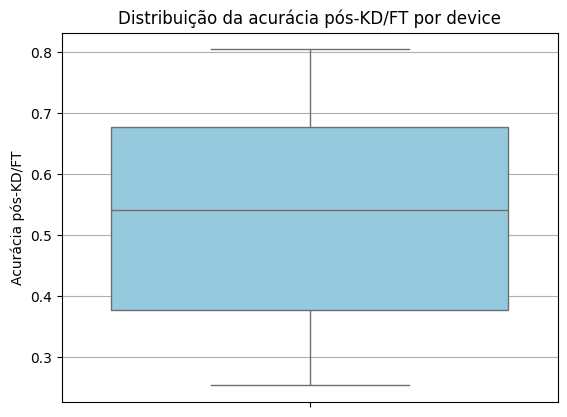

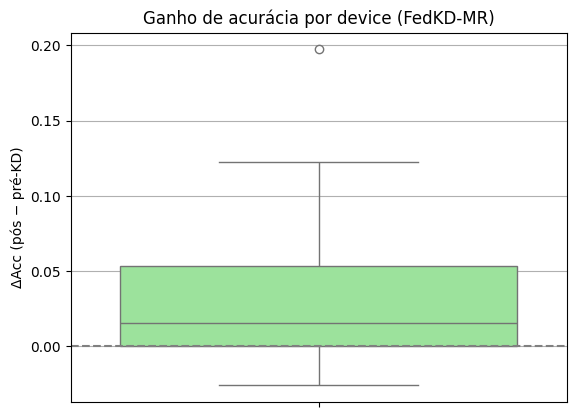

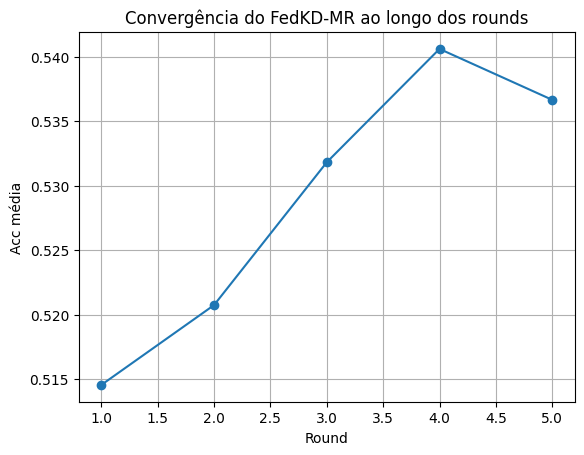

In [ ]:
# ID = 20A — Gráficos principais do experimento HAR (paper-grade)
# ---------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# === Paths ===
DEVICES_POSKD_CSV = METRICS_DIR / f"{EXPERIMENT_ID}_devices_posKD_FT_metrics.csv"
DELTAS_CSV        = METRICS_DIR / f"{EXPERIMENT_ID}_round_{N_ROUNDS:02d}_devices_deltas_pre_vs_post.csv"
SUMMARY_CSV       = METRICS_DIR / f"{EXPERIMENT_ID}_summary_rounds_posKD_FT.csv"

# === Load data ===
devices_df = pd.read_csv(DEVICES_POSKD_CSV)
deltas_df  = pd.read_csv(DELTAS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

# ===============================================================
# Figura 1 — Boxplot Acc pós-KD/FT (round final)
# ===============================================================
final_df = devices_df[devices_df["round"] == N_ROUNDS]

plt.figure()
sns.boxplot(
    data=final_df,
    y="acc_test",
    color="skyblue"
)
plt.ylabel("Acurácia pós-KD/FT")
plt.title("Distribuição da acurácia pós-KD/FT por device")
plt.grid(True, axis="y")
plt.show()

# ===============================================================
# Figura 2 — Boxplot ΔAcc por device (round final)
# ===============================================================
plt.figure()
sns.boxplot(
    data=deltas_df,
    y="delta_acc_test",
    color="lightgreen"
)
plt.axhline(0, ls="--", c="gray")
plt.ylabel("ΔAcc (pós − pré-KD)")
plt.title("Ganho de acurácia por device (FedKD-MR)")
plt.grid(True, axis="y")
plt.show()

# ===============================================================
# Figura 3 — Convergência: Acc_mean × rounds
# ===============================================================
plt.figure()
plt.plot(
    summary_df["round"],
    summary_df["acc_mean"],
    marker="o"
)
plt.xlabel("Round")
plt.ylabel("Acc média")
plt.title("Convergência do FedKD-MR ao longo dos rounds")
plt.grid(True)
plt.show()

In [ ]:
# ID = 21 — Hiperparâmetros Federados (FedAvg / FedProx)
# ------------------------------------------------------

BASELINE_CONFIG_INFO = {
    "baseline_comparison_mode": BASELINE_COMPARISON_MODE,
    "n_rounds": int(N_ROUNDS),
    "local_epochs": int(LOCAL_EPOCHS),
    "lr": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "max_grad_norm": float(MAX_GRAD_NORM),
    "fedprox_mu": float(FEDPROX_MU),
    "budget_note": (
        "Baselines com orçamento reduzido em relação ao FedKD-MR."
        if BASELINE_COMPARISON_MODE == "light_baseline"
        else "Baselines ajustados para comparação mais próxima em orçamento local."
    ),
    "comparison_warning": (
        "FedAvg/FedProx e FedKD-MR ainda não são perfeitamente equiparáveis em custo, "
        "pois FedKD-MR inclui KD em conjunto público além do treino supervisionado local."
    ),
}

print("✅ Hiperparâmetros federados carregados da configuração central")
print(f"- BASELINE_COMPARISON_MODE = {BASELINE_COMPARISON_MODE}")
print(f"- N_ROUNDS                 = {N_ROUNDS}")
print(f"- LOCAL_EPOCHS             = {LOCAL_EPOCHS}")
print(f"- LR                       = {LR}")
print(f"- WEIGHT_DECAY             = {WEIGHT_DECAY}")
print(f"- BATCH_SIZE               = {BATCH_SIZE}")
print(f"- MAX_GRAD_NORM            = {MAX_GRAD_NORM}")
print(f"- FEDPROX_MU               = {FEDPROX_MU}")

✅ Hiperparâmetros federados carregados da configuração central
- BASELINE_COMPARISON_MODE = light_baseline
- N_ROUNDS                 = 5
- LOCAL_EPOCHS             = 1
- LR                       = 0.001
- WEIGHT_DECAY             = 0.0001
- BATCH_SIZE               = 64
- MAX_GRAD_NORM            = 5.0
- FEDPROX_MU               = 0.01


In [ ]:
# ID = 22 — CNN-1D Canônica (Baseline FedAvg / FedProx) — corrigida
# -----------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN1DCanonical(nn.Module):
    """
    CNN-1D canônica para HAR, usada como baseline homogêneo
    em FedAvg e FedProx.

    Observação metodológica:
    - Esta arquitetura é única e compartilhada por todos os clientes.
    - Portanto, ela representa um baseline federado homogêneo.
    - Não é diretamente equivalente ao cenário heterogêneo do FedKD-MR.
    """

    def __init__(
        self,
        n_channels: int,
        n_classes: int,
        conv1_out: int = 64,
        conv2_out: int = 128,
        hidden_dim: int = 128,
        dropout: float = 0.5,
    ):
        super().__init__()

        self.n_channels = n_channels
        self.n_classes = n_classes
        self.conv1_out = conv1_out
        self.conv2_out = conv2_out
        self.hidden_dim = hidden_dim
        self.dropout_p = dropout

        # Bloco Conv 1
        self.conv1 = nn.Conv1d(
            in_channels=n_channels,
            out_channels=conv1_out,
            kernel_size=5,
            padding=2
        )
        self.bn1 = nn.BatchNorm1d(conv1_out)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Bloco Conv 2
        self.conv2 = nn.Conv1d(
            in_channels=conv1_out,
            out_channels=conv2_out,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm1d(conv2_out)

        # Classificador
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(conv2_out, hidden_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        # Esperado: x com shape [B, C, T]
        if x.ndim != 3:
            raise ValueError(f"Esperado tensor 3D [B, C, T], mas recebido shape={tuple(x.shape)}")

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.gap(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc_out(x)
        return x

    def get_config(self):
        return {
            "model_name": "CNN1DCanonical",
            "n_channels": self.n_channels,
            "n_classes": self.n_classes,
            "conv1_out": self.conv1_out,
            "conv2_out": self.conv2_out,
            "hidden_dim": self.hidden_dim,
            "dropout": self.dropout_p,
            "architecture_type": "homogeneous_baseline",
        }


# ----------------------------------------------------
# Helper opcional para instanciar baseline canônico
# ----------------------------------------------------
def build_canonical_federated_model(input_shape, n_classes):
    """
    Cria a CNN-1D canônica para FedAvg/FedProx.

    input_shape esperado: (C, T)
    """
    if not isinstance(input_shape, (tuple, list)) or len(input_shape) != 2:
        raise ValueError(f"input_shape inválido para CNN1DCanonical: {input_shape}")

    n_channels = int(input_shape[0])

    model = CNN1DCanonical(
        n_channels=n_channels,
        n_classes=int(n_classes),
    )

    return model


In [ ]:
# ID = 23
# --------------------------------------------------------------------
def build_cnn1d_canonical(input_shape, n_classes):
    """
    Wrapper compatível com o notebook atual.
    Cria a CNN-1D canônica usada nos baselines FedAvg / FedProx.

    input_shape esperado: (C, T)
    """
    if not isinstance(input_shape, (tuple, list)) or len(input_shape) != 2:
        raise ValueError(f"input_shape inválido: {input_shape}")

    n_channels, _ = input_shape  # (C, T)

    return CNN1DCanonical(
        n_channels=int(n_channels),
        n_classes=int(n_classes)
    )

In [ ]:
# ID = 24
# --------------------------------------------------------------------
model = build_cnn1d_canonical(
    input_shape=INPUT_SHAPE,
    n_classes=N_CLASSES
)

n_params = sum(p.numel() for p in model.parameters())

BASELINE_MODEL_INFO = {
    "model_name": "CNN1DCanonical",
    "input_shape": tuple(INPUT_SHAPE),
    "n_classes": int(N_CLASSES),
    "n_params": int(n_params),
    "architecture_type": "homogeneous_baseline",
}

print(f"✅ Modelo baseline instanciado: {BASELINE_MODEL_INFO['model_name']}")
print(f" - input_shape        = {BASELINE_MODEL_INFO['input_shape']}")
print(f" - n_classes          = {BASELINE_MODEL_INFO['n_classes']}")
print(f" - n_params           = {BASELINE_MODEL_INFO['n_params']:,}")
print(f" - architecture_type  = {BASELINE_MODEL_INFO['architecture_type']}")

✅ Modelo baseline instanciado: CNN1DCanonical
 - input_shape        = (3, 128)
 - n_classes          = 6
 - n_params           = 43,398
 - architecture_type  = homogeneous_baseline


In [ ]:
# ID = 25
# --------------------------------------------------------------------
def fedavg_aggregate(local_weights, local_sizes):
    """
    Agregação FedAvg com suporte a parâmetros float e não-float.

    Parâmetros
    ----------
    local_weights : list[dict[str, torch.Tensor]]
        Lista de state_dicts locais.
    local_sizes : list[int]
        Número de amostras de treino usadas por cada cliente.

    Observação metodológica
    -----------------------
    local_sizes deve refletir apenas o conjunto de treino de cada cliente.
    Não usar contagens misturando treino e teste.
    """
    assert len(local_weights) == len(local_sizes), \
        "local_weights e local_sizes devem ter o mesmo comprimento."
    assert len(local_weights) > 0, "local_weights não pode ser vazio."
    assert all(size >= 0 for size in local_sizes), "local_sizes contém valor negativo."

    total_samples = sum(local_sizes)
    assert total_samples > 0, "A soma de local_sizes deve ser > 0."

    agg_weights = {}

    for k in local_weights[0].keys():
        ref_tensor = local_weights[0][k]

        # Parâmetros não float: copiar diretamente
        if not torch.is_floating_point(ref_tensor):
            agg_weights[k] = ref_tensor.clone()
            continue

        # Inicialização
        agg_weights[k] = torch.zeros_like(ref_tensor)

        # Média ponderada
        for w, size in zip(local_weights, local_sizes):
            agg_weights[k] += (size / total_samples) * w[k]

    return agg_weights

In [ ]:
# ID = 26 — Treino Local FedProx (corrigido)
# -----------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim


def train_local_model_fedprox(
    model,
    global_weights,
    train_loader,
    n_epochs,
    lr,
    mu,
    weight_decay,
    max_grad_norm,
    device,
    desc=""
):
    """
    Treino local com regularização FedProx.

    Args:
        model (nn.Module): modelo local inicializado com pesos globais
        global_weights (Dict[str, Tensor]): state_dict do modelo global
        train_loader (DataLoader): loader de TREINO local do cliente
        n_epochs (int): epochs locais
        lr (float): learning rate
        mu (float): coeficiente proximal do FedProx
        weight_decay (float): weight decay
        max_grad_norm (float | None): clipping de gradiente
        device (torch.device | str)
        desc (str): descrição opcional

    Returns:
        dict: estatísticas simples de treino
    """

    assert train_loader is not None, f"{desc} | train_loader é None"
    assert len(train_loader.dataset) > 0, f"{desc} | train_loader sem amostras"

    model = model.to(device)
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # Congela pesos globais para o termo proximal
    global_weights = {
        k: v.detach().to(device)
        for k, v in global_weights.items()
    }

    stats = {
        "last_train_loss": None,
        "n_epochs": int(n_epochs),
        "n_batches": int(len(train_loader)),
        "n_samples": int(len(train_loader.dataset)),
        "mu": float(mu),
    }

    for epoch in range(n_epochs):
        epoch_loss = 0.0

        for x, y in train_loader:
            x = x.to(device, non_blocking=False)
            y = y.to(device, non_blocking=False)

            optimizer.zero_grad()

            # Forward
            logits = model(x)
            loss = criterion(logits, y)

            # Termo proximal FedProx
            prox_term = 0.0
            for name, param in model.named_parameters():
                prox_term = prox_term + torch.sum((param - global_weights[name]) ** 2)

            loss = loss + (mu / 2.0) * prox_term

            # Backward
            loss.backward()

            if max_grad_norm is not None and max_grad_norm > 0:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_grad_norm
                )

            optimizer.step()

            epoch_loss += loss.item()

        stats["last_train_loss"] = epoch_loss / max(1, len(train_loader))

    return stats

In [ ]:
# ID = 27 — FedAvg (CNN-1D canônica) — corrigido
# ----------------------------------------------

global_model = build_cnn1d_canonical(
    input_shape=INPUT_SHAPE,
    n_classes=N_CLASSES
).to(DEVICE)

global_weights = copy.deepcopy(global_model.state_dict())

fedavg_summary = []
fedavg_device_records = []

for r in range(1, N_ROUNDS + 1):
    print(f"\n========== FedAvg — ROUND {r} ==========")

    local_weights = []
    local_sizes = []

    # -------------------------------------------------
    # 1) Treino local em dados de TREINO
    # -------------------------------------------------
    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]

        assert train_loader is not None, f"FedAvg round {r} | train_loader ausente para device {did}"
        assert len(train_loader.dataset) > 0, f"FedAvg round {r} | sem treino para device {did}"

        local_model = build_cnn1d_canonical(
            input_shape=INPUT_SHAPE,
            n_classes=N_CLASSES
        ).to(DEVICE)

        local_model.load_state_dict(global_weights)

        train_stats = train_local_model(
            model=local_model,
            train_loader=train_loader,
            n_epochs=LOCAL_EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            max_grad_norm=MAX_GRAD_NORM,
            device=DEVICE,
            desc=f"fedavg_r{r}_dev{did:02d}",
            eval_loader=None,
            track_metrics=False,
        )

        local_weights.append(copy.deepcopy(local_model.state_dict()))
        local_sizes.append(int(len(train_loader.dataset)))

    # -------------------------------------------------
    # 2) Agregação FedAvg
    # -------------------------------------------------
    global_weights = fedavg_aggregate(local_weights, local_sizes)
    global_model.load_state_dict(global_weights)

    # -------------------------------------------------
    # 3) Avaliação do modelo global em TESTE por cliente
    # -------------------------------------------------
    acc_list = []
    f1_list = []

    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]
        test_loader = CLIENT_TEST_LOADERS[idx]

        n_train = int(client_n_train_samples[idx])
        n_test = int(client_n_test_samples[idx])

        assert test_loader is not None, f"FedAvg round {r} | test_loader ausente para device {did}"
        assert len(test_loader.dataset) > 0, f"FedAvg round {r} | sem teste para device {did}"

        metrics_train = evaluate_model(
            global_model,
            train_loader,
            device=DEVICE
        )

        metrics_test = evaluate_model(
            global_model,
            test_loader,
            device=DEVICE
        )

        acc_train = float(metrics_train["acc"])
        f1_train = float(metrics_train["f1_macro"])

        acc_test = float(metrics_test["acc"])
        f1_test = float(metrics_test["f1_macro"])

        gap_acc = acc_train - acc_test

        acc_list.append(acc_test)
        f1_list.append(f1_test)

        fedavg_device_records.append({
            "dataset": EXPERIMENT_CFG["dataset"],
            "method": "FedAvg",
            "round": int(r),
            "device_id": did,

            "n_train_samples": n_train,
            "n_test_samples": n_test,
            "n_eval_samples": n_test,

            "train_loader_type": "CLIENT_TRAIN_LOADERS",
            "test_loader_type": "CLIENT_TEST_LOADERS",
            "eval_split": "test",

            "local_epochs": int(LOCAL_EPOCHS),
            "lr": float(LR),
            "weight_decay": float(WEIGHT_DECAY),

            "acc_train": acc_train,
            "f1_macro_train": f1_train,
            "acc_test": acc_test,
            "f1_macro_test": f1_test,
            "gap_acc_train_test": float(gap_acc),
        })

    # -------------------------------------------------
    # 4) Agregados de fairness e desempenho
    # -------------------------------------------------
    acc_arr = np.array(acc_list, dtype=float)

    acc_mean = float(np.mean(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_std = float(np.std(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_min = float(np.min(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_max = float(np.max(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_range = float(acc_max - acc_min) if acc_arr.size > 0 else float("nan")
    jain = jain_index(acc_arr)

    worst_idx = int(np.argmin(acc_arr)) if acc_arr.size > 0 else None
    best_idx = int(np.argmax(acc_arr)) if acc_arr.size > 0 else None

    worst_device_id = int(device_ids[worst_idx]) if worst_idx is not None else None
    best_device_id = int(device_ids[best_idx]) if best_idx is not None else None

    fedavg_summary.append({
        "dataset": EXPERIMENT_CFG["dataset"],
        "method": "FedAvg",
        "round": int(r),
        "eval_split": "test",

        "n_devices": int(len(device_ids)),
        "local_epochs": int(LOCAL_EPOCHS),

        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "acc_min": acc_min,
        "acc_max": acc_max,
        "acc_range": acc_range,
        "jain": jain,

        "worst_device_id": worst_device_id,
        "best_device_id": best_device_id,
    })

    print(
        f"[FedAvg] TEST acc_mean={acc_mean:.4f}, "
        f"acc_min={acc_min:.4f}, acc_max={acc_max:.4f}, "
        f"range={acc_range:.4f}, Jain={jain:.4f}"
    )

# -------------------------------------------------
# DataFrames + checks
# -------------------------------------------------
fedavg_summary_df = pd.DataFrame(fedavg_summary)
fedavg_device_df = pd.DataFrame(fedavg_device_records)

assert not fedavg_summary_df.empty, "fedavg_summary_df ficou vazio."
assert not fedavg_device_df.empty, "fedavg_device_df ficou vazio."
assert (fedavg_device_df["eval_split"] == "test").all(), "FedAvg não está sendo avaliado integralmente em teste."
assert (fedavg_device_df["n_test_samples"] > 0).all(), "Há device sem teste no FedAvg."
assert np.allclose(
    fedavg_device_df["gap_acc_train_test"].values,
    fedavg_device_df["acc_train"].values - fedavg_device_df["acc_test"].values
), "gap_acc_train_test inconsistente no FedAvg."

# -------------------------------------------------
# Salvamento opcional
# -------------------------------------------------
fedavg_summary_csv = METRICS_DIR / f"{EXPERIMENT_ID}_fedavg_summary.csv"
fedavg_device_csv = METRICS_DIR / f"{EXPERIMENT_ID}_fedavg_device_metrics.csv"

fedavg_summary_df.to_csv(fedavg_summary_csv, index=False)
fedavg_device_df.to_csv(fedavg_device_csv, index=False)

print(f"✅ FedAvg summary salvo em: {fedavg_summary_csv}")
print(f"✅ FedAvg por device salvo em: {fedavg_device_csv}")


========== FedAvg — ROUND 1 ==========
[FedAvg] TEST acc_mean=0.1907, acc_min=0.1429, acc_max=0.2308, range=0.0879, Jain=0.9881

========== FedAvg — ROUND 2 ==========
[FedAvg] TEST acc_mean=0.1920, acc_min=0.1429, acc_max=0.2500, range=0.1071, Jain=0.9851

========== FedAvg — ROUND 3 ==========
[FedAvg] TEST acc_mean=0.2139, acc_min=0.1429, acc_max=0.3194, range=0.1766, Jain=0.9490

========== FedAvg — ROUND 4 ==========
[FedAvg] TEST acc_mean=0.3325, acc_min=0.1341, acc_max=0.5088, range=0.3746, Jain=0.9442

========== FedAvg — ROUND 5 ==========
[FedAvg] TEST acc_mean=0.4123, acc_min=0.2683, acc_max=0.5077, range=0.2394, Jain=0.9749
✅ FedAvg summary salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_fedavg_summary.csv
✅ FedAvg por device salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_

In [ ]:
# ID = 28 — FedProx (CNN-1D canônica) — corrigido
# -----------------------------------------------

global_model = build_cnn1d_canonical(
    input_shape=INPUT_SHAPE,
    n_classes=N_CLASSES
).to(DEVICE)

global_weights = copy.deepcopy(global_model.state_dict())

fedprox_summary = []
fedprox_device_records = []

for r in range(1, N_ROUNDS + 1):
    print(f"\n========== FedProx — ROUND {r} ==========")

    local_weights = []
    local_sizes = []

    # -------------------------------------------------
    # 1) Treino local em dados de TREINO
    # -------------------------------------------------
    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]

        assert train_loader is not None, f"FedProx round {r} | train_loader ausente para device {did}"
        assert len(train_loader.dataset) > 0, f"FedProx round {r} | sem treino para device {did}"

        local_model = build_cnn1d_canonical(
            input_shape=INPUT_SHAPE,
            n_classes=N_CLASSES
        ).to(DEVICE)

        local_model.load_state_dict(global_weights)

        train_stats = train_local_model_fedprox(
            model=local_model,
            global_weights=global_weights,
            train_loader=train_loader,
            n_epochs=LOCAL_EPOCHS,
            lr=LR,
            mu=FEDPROX_MU,
            weight_decay=WEIGHT_DECAY,
            max_grad_norm=MAX_GRAD_NORM,
            device=DEVICE,
            desc=f"fedprox_r{r}_dev{did:02d}",
        )

        local_weights.append(copy.deepcopy(local_model.state_dict()))
        local_sizes.append(int(len(train_loader.dataset)))

    # -------------------------------------------------
    # 2) Agregação (mesma regra do FedAvg)
    # -------------------------------------------------
    global_weights = fedavg_aggregate(local_weights, local_sizes)
    global_model.load_state_dict(global_weights)

    # -------------------------------------------------
    # 3) Avaliação do modelo global em TESTE por cliente
    # -------------------------------------------------
    acc_list = []
    f1_list = []

    for idx, did in enumerate(device_ids):
        train_loader = CLIENT_TRAIN_LOADERS[idx]
        test_loader = CLIENT_TEST_LOADERS[idx]

        n_train = int(client_n_train_samples[idx])
        n_test = int(client_n_test_samples[idx])

        assert test_loader is not None, f"FedProx round {r} | test_loader ausente para device {did}"
        assert len(test_loader.dataset) > 0, f"FedProx round {r} | sem teste para device {did}"

        metrics_train = evaluate_model(
            global_model,
            train_loader,
            device=DEVICE
        )

        metrics_test = evaluate_model(
            global_model,
            test_loader,
            device=DEVICE
        )

        acc_train = float(metrics_train["acc"])
        f1_train = float(metrics_train["f1_macro"])

        acc_test = float(metrics_test["acc"])
        f1_test = float(metrics_test["f1_macro"])

        gap_acc = acc_train - acc_test

        acc_list.append(acc_test)
        f1_list.append(f1_test)

        fedprox_device_records.append({
            "dataset": EXPERIMENT_CFG["dataset"],
            "method": "FedProx",
            "round": int(r),
            "device_id": did,

            "n_train_samples": n_train,
            "n_test_samples": n_test,
            "n_eval_samples": n_test,

            "train_loader_type": "CLIENT_TRAIN_LOADERS",
            "test_loader_type": "CLIENT_TEST_LOADERS",
            "eval_split": "test",

            "local_epochs": int(LOCAL_EPOCHS),
            "lr": float(LR),
            "mu": float(FEDPROX_MU),
            "weight_decay": float(WEIGHT_DECAY),

            "acc_train": acc_train,
            "f1_macro_train": f1_train,
            "acc_test": acc_test,
            "f1_macro_test": f1_test,
            "gap_acc_train_test": float(gap_acc),
        })

    # -------------------------------------------------
    # 4) Agregados de fairness e desempenho
    # -------------------------------------------------
    acc_arr = np.array(acc_list, dtype=float)

    acc_mean = float(np.mean(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_std = float(np.std(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_min = float(np.min(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_max = float(np.max(acc_arr)) if acc_arr.size > 0 else float("nan")
    acc_range = float(acc_max - acc_min) if acc_arr.size > 0 else float("nan")
    jain = jain_index(acc_arr)

    worst_idx = int(np.argmin(acc_arr)) if acc_arr.size > 0 else None
    best_idx = int(np.argmax(acc_arr)) if acc_arr.size > 0 else None

    worst_device_id = int(device_ids[worst_idx]) if worst_idx is not None else None
    best_device_id = int(device_ids[best_idx]) if best_idx is not None else None

    fedprox_summary.append({
        "dataset": EXPERIMENT_CFG["dataset"],
        "method": "FedProx",
        "round": int(r),
        "eval_split": "test",

        "n_devices": int(len(device_ids)),
        "local_epochs": int(LOCAL_EPOCHS),
        "mu": float(FEDPROX_MU),

        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "acc_min": acc_min,
        "acc_max": acc_max,
        "acc_range": acc_range,
        "jain": jain,

        "worst_device_id": worst_device_id,
        "best_device_id": best_device_id,
    })

    print(
        f"[FedProx] TEST acc_mean={acc_mean:.4f}, "
        f"acc_min={acc_min:.4f}, acc_max={acc_max:.4f}, "
        f"range={acc_range:.4f}, Jain={jain:.4f}"
    )

# -------------------------------------------------
# DataFrames + checks
# -------------------------------------------------
fedprox_summary_df = pd.DataFrame(fedprox_summary)
fedprox_device_df = pd.DataFrame(fedprox_device_records)

assert not fedprox_summary_df.empty, "fedprox_summary_df ficou vazio."
assert not fedprox_device_df.empty, "fedprox_device_df ficou vazio."
assert (fedprox_device_df["eval_split"] == "test").all(), "FedProx não está sendo avaliado integralmente em teste."
assert (fedprox_device_df["n_test_samples"] > 0).all(), "Há device sem teste no FedProx."
assert np.allclose(
    fedprox_device_df["gap_acc_train_test"].values,
    fedprox_device_df["acc_train"].values - fedprox_device_df["acc_test"].values
), "gap_acc_train_test inconsistente no FedProx."

# -------------------------------------------------
# Salvamento opcional
# -------------------------------------------------
fedprox_summary_csv = METRICS_DIR / f"{EXPERIMENT_ID}_fedprox_summary.csv"
fedprox_device_csv = METRICS_DIR / f"{EXPERIMENT_ID}_fedprox_device_metrics.csv"

fedprox_summary_df.to_csv(fedprox_summary_csv, index=False)
fedprox_device_df.to_csv(fedprox_device_csv, index=False)

print(f"✅ FedProx summary salvo em: {fedprox_summary_csv}")
print(f"✅ FedProx por device salvo em: {fedprox_device_csv}")


========== FedProx — ROUND 1 ==========
[FedProx] TEST acc_mean=0.1907, acc_min=0.1429, acc_max=0.2308, range=0.0879, Jain=0.9881

========== FedProx — ROUND 2 ==========
[FedProx] TEST acc_mean=0.1933, acc_min=0.1429, acc_max=0.2778, range=0.1349, Jain=0.9804

========== FedProx — ROUND 3 ==========
[FedProx] TEST acc_mean=0.2248, acc_min=0.1429, acc_max=0.4000, range=0.2571, Jain=0.9272

========== FedProx — ROUND 4 ==========
[FedProx] TEST acc_mean=0.3516, acc_min=0.1594, acc_max=0.4848, range=0.3254, Jain=0.9481

========== FedProx — ROUND 5 ==========
[FedProx] TEST acc_mean=0.5052, acc_min=0.3659, acc_max=0.6714, range=0.3056, Jain=0.9778
✅ FedProx summary salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5_fedprox_summary.csv
✅ FedProx por device salvo em: /content/drive/MyDrive/FedKD_MR_HAR_results/UCI_HAR_C3_partial_coverage_512_T3_tau07_KD8_FT8_R5/metrics/UCI_HA